
# Bayesian model selection

An overview of Bayesian model selection combining gammapy with ultranest and arziv packages. 


## Context

For a general overview see:
- https://arviz-devs.github.io/EABM/Chapters/Model_comparison.html
- https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html

Here we are going to focus on the following questions:
- What are the comon information criterion used for model selection nowadays  ?
- how the parameter posterior is sensitive to the choice of prior ?
- how model comparison is sensitive to the choice of prior ?


## Proposed approach

In this example, we will perform a Bayesian analysis with multiple 1D
spectra of the Crab nebula data. Then we will discuss how to interpret the posterior
distributions, the sensitivity to prior of the different information criterion used for model selection, and how to define the priors.




## Setup

As usual, we’ll start with some setup …




In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
from gammapy.datasets import Datasets
from gammapy.datasets import SpectrumDatasetOnOff

from gammapy.modeling.models import (
    SkyModel,
    UniformPrior,
    LogUniformPrior,
    GaussianPrior,
)

from gammapy.modeling.sampler import Sampler

## Loading the spectral datasets

Here we will load a few Crab 1D spectral data for which we will do a
fit.




In [2]:
path = "$GAMMAPY_DATA/joint-crab/spectra/hess/"

datasets = Datasets()
for id in ["23523", "23526", "23559", "23592"]:
    dataset = SpectrumDatasetOnOff.read(f"{path}pha_obs{id}.fits")
    datasets.append(dataset)

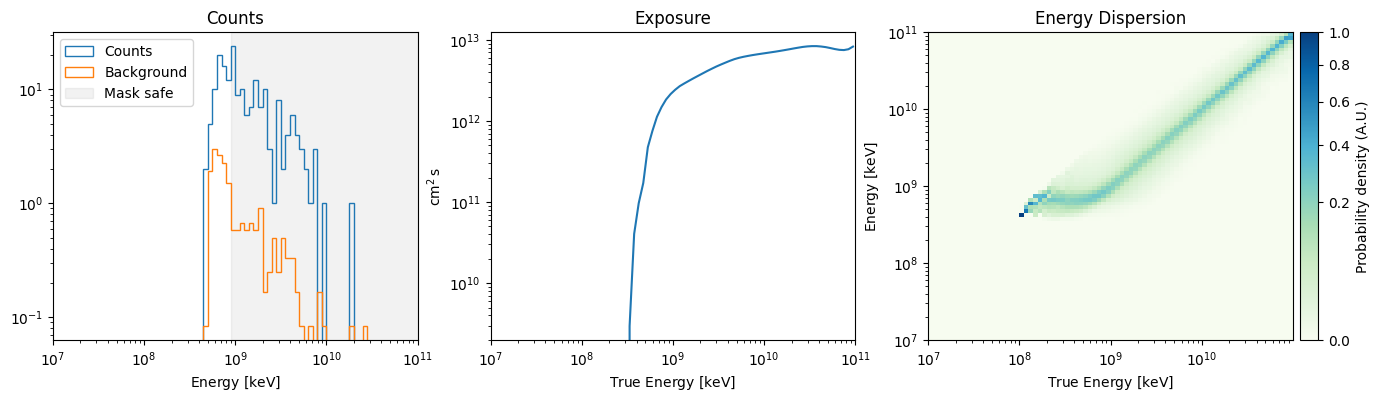

In [3]:
datasets[0].peek()

## Model definition

Now we want to define the spectral model that will be fitted to the
data.
The Crab spectra will be fitted here with a simple powerlaw for
simplicity.




In [4]:
model_type = "lp"

In [5]:
model = SkyModel.create(spectral_model=model_type, name="crab")

.. WARNING:: Priors definition:
   Unlike a traditional fit where priors on the
   parameters are optional, here it is inherent to the Bayesian approach and
   are therefore mandatory.

In this case we will set (min,max) prior that will define the
boundaries in which the sampling will be performed.
Note that it is usually recommended to use a `~gammapy.modeling.models.LogUniformPrior` for
the parameters that have a large amplitude range like the
``amplitude`` parameter.
A `~gammapy.modeling.models.UniformPrior` means that the samples will be drawn with uniform
probability between the (min,max) values in the linear or log space
in the case of a `~gammapy.modeling.models.LogUniformPrior`.




In [6]:
from gammapy.modeling.models import create_crab_spectral_model

ref_model = create_crab_spectral_model("magic_lp")

In [7]:
ref_model

In [8]:
# add rv to gaussian gammapy prior (the rv should be a property of the prior so we don't have to do that)
from scipy.stats import norm, uniform, loguniform


@property
def norm_rv(self):
    """Return random variable object for prior."""
    return norm(self.mu.value, self.sigma.value)


GaussianPrior.rv = norm_rv


@property
def uniform_rv(self):
    """Return random variable object for prior."""
    return uniform(self.min.value, self.max.value - self.min.value)


@property
def loguniform_rv(self):
    """Return random variable object for prior."""
    return loguniform(self.min.value, self.max.value)


GaussianPrior.rv = norm_rv
UniformPrior.rv = uniform_rv
LogUniformPrior.rv = loguniform_rv

Let's define prior of different strenght.
Names are qualitatives.

In [9]:
# prior_type = "uniformative"
prior_type = "diffuse"
# prior_type = "weak"
# prior_type = "strong"

if prior_type == "uniformative":
    model.spectral_model.amplitude.prior = LogUniformPrior(min=1e-13, max=1e-9)
    model.spectral_model.alpha.prior = UniformPrior(min=0, max=10)
    model.spectral_model.beta.prior = UniformPrior(min=0, max=10)
elif prior_type == "diffuse":
    model.spectral_model.amplitude.prior = LogUniformPrior(min=1e-13, max=1e-9)
    model.spectral_model.alpha.prior = GaussianPrior(mu=ref_model.alpha.value, sigma=5)
    model.spectral_model.beta.prior = GaussianPrior(mu=ref_model.beta.value, sigma=1)
elif prior_type == "weak":
    model.spectral_model.amplitude.prior = LogUniformPrior(min=1e-13, max=1e-9)
    model.spectral_model.alpha.prior = GaussianPrior(mu=ref_model.alpha.value, sigma=2)
    model.spectral_model.beta.prior = UniformPrior(min=0, max=1)
elif prior_type == "strong":
    model.spectral_model.amplitude.prior = LogUniformPrior(min=1e-11, max=1e-10)
    model.spectral_model.alpha.prior = GaussianPrior(
        mu=ref_model.alpha.value, sigma=0.1
    )
    model.spectral_model.beta.prior = GaussianPrior(mu=ref_model.beta.value, sigma=0.1)
elif prior_type == "custom":
    pass

model.spectral_model.reference.value = 1
datasets.models = [model]
print(datasets.models)

DatasetModels

Component 0: SkyModel

  Name                      : crab
  Datasets names            : None
  Spectral model type       : LogParabolaSpectralModel
  Spatial  model type       : 
  Temporal model type       : 
  Parameters:
    amplitude                     :   1.00e-12   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      1.000       TeV         
    alpha                         :      2.000   +/-    0.00             
    beta                          :      1.000   +/-    0.00             




## Defining the sampler and options


In [10]:
sampler_opts = {
    "live_points": 500,
    "frac_remain": 0.1,
    "log_dir": None,
}

sampler = Sampler(backend="ultranest", sampler_opts=sampler_opts)

Next we can run the sampler on a given dataset.
No options are accepted in the run method.




In [11]:
import time

max_try = 5
completed = False
n_try = 0
# the prior is particualrly bad so it go result where the likelihood has not finite (nan/inf)
# so we had an itertive attemps mecanism
while not completed and n_try < max_try:
    n_try += 1
    zero_time = time.time()
    try:
        result_joint = sampler.run(datasets)
        sampler_time = time.time() - zero_time
        print("sampler time", sampler_time)
    except AssertionError:
        pass
    completed = True

[ultranest] Sampling 500 live points from prior ...


/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/qremy/Work/GitHub/gammapy/gammapy/datasets/core.py:260: RuntimeWarning: overflow encountered in scalar add
  stat_sum += dataset._stat_sum_likelihood()


[ultranest] Widening roots to 536 live points (have 500 already) ...
[ultranest] Sampling 36 live points from prior ...
[ultranest] Widening roots to 573 live points (have 536 already) ...
[ultranest] Sampling 37 live points from prior ...


/Users/qremy/Work/GitHub/gammapy/gammapy/datasets/core.py:260: RuntimeWarning: overflow encountered in scalar add
  stat_sum += dataset._stat_sum_likelihood()


/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


[ultranest] Explored until L=-8e+01   [-76.3444..-76.3439]*| it/evals=6441/12694 eff=52.5369% N=500   
[ultranest] Likelihood function evaluations: 12704
[ultranest]   logZ = -86.84 +- 0.102
[ultranest] Effective samples strategy satisfied (ESS = 2357.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.10 total:0.14 required:<0.50
[ultranest] done iterating.

logZ = -86.791 +- 0.182
  single instance: logZ = -86.791 +- 0.135
  bootstrapped   : logZ = -86.836 +- 0.155
  tail           : logZ = +- 0.095
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000337│ ▁▁▁▁▁▁▁▁▂▃▄▄▄▆▇▇▇▇▇▆▅▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁ │0.0000000000579    0.0000000000446 +- 0.0000000000030
    alpha               : 1.58  │ ▁▁▁▁▁▁▁▁▂▂▃▃▅▆▆▇▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁   ▁ │3.18      2.32 +- 0.19

The `~gammapy.modeling.Sampler` class returns a very rich dictionary.
The most “standard” information about the posterior distributions can
be found in :




In [12]:
print(result_joint.sampler_results["posterior"])

{'mean': [4.464854410856226e-11, 2.321648203928566, 0.21570090583509607], 'stdev': [2.987591830259524e-12, 0.18701133761127667, 0.09820159278052713], 'median': [4.452225166822562e-11, 2.324178229698437, 0.21125343168813554], 'errlo': [4.1645164902472265e-11, 2.134706150567541, 0.11687320202334266], 'errup': [4.757211251201629e-11, 2.509114250512023, 0.31429635028170877], 'information_gain_bits': [3.6609353322102627, 3.1157487227041756, 1.5909778787615387]}


Besides mean, errors, etc, an interesting value is the
``information gain`` which estimates how much the posterior
distribution has shrinked with respect to the prior (i.e. how much
we’ve learned). A value < 1 means that the parameter is poorly
constrained within the prior range (we haven't learned much with respect to our prior assumption).
For a physical example see this
[example](https://arxiv.org/abs/2205.00009)_.


One of the strength of the Bayesian
analysis is to be able to visualise all parameters correlations which is usually
done using “corner plots”.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


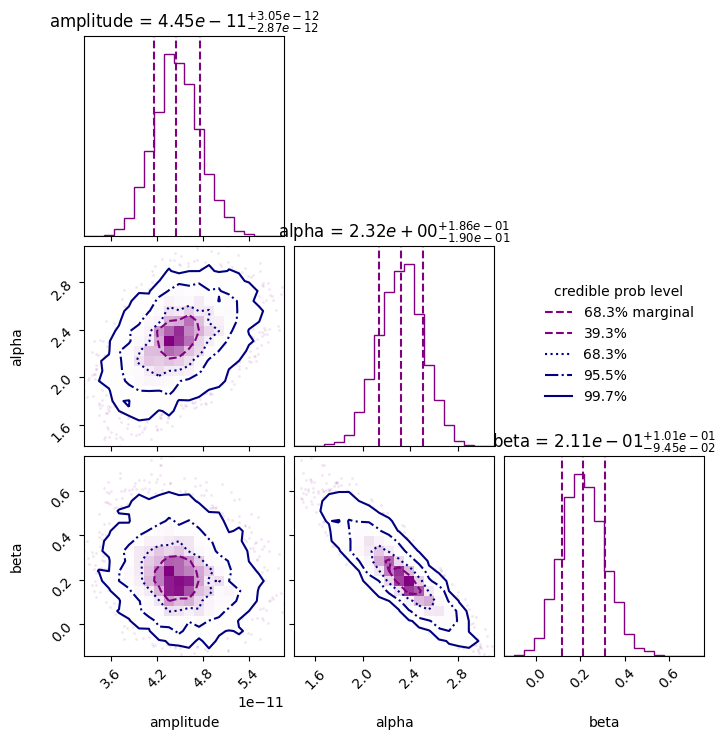

In [13]:
from ultranest.plot import cornerplot

cornerplot(
    result_joint.sampler_results,
    plot_datapoints=True,
    plot_density=True,
    bins=20,
    title_fmt=".2e",
    smooth=False,
)
plt.show()

# Using ArviZ package for diagnostics

ArviZ package contains contains a number of utilities to visualize and interpret the output of the samplers. \
https://python.arviz.org/en/latest/index.html

Here we are going to convert ultranest sampler result to an ArviZ InferenceData object.

In [14]:
# %% convert ultranest sampler result to ArviZ InferenceData
import arviz as az
import xarray as xr


def inference_data_from_ultranest(sampler_results, weighted=False):
    """
    Convert UltraNest result dictionary to ArviZ InferenceData.

    Parameters
    ----------
    result : dict
        The result dictionary returned by `ReactiveNestedSampler.run()`.

    Returns
    -------
    arviz.InferenceData
    """

    var_names = sampler_results["paramnames"]

    if weighted:
        ws = sampler_results["weighted_samples"]

        # Posterior samples (1 chain)
        posterior_data = {
            var: (["chain", "draw"], ws["points"][:, i][np.newaxis, :])
            for i, var in enumerate(var_names)
        }
        posterior = xr.Dataset(posterior_data)

        unconstrained_posterior_data = {
            var: (["chain", "draw"], ws["upoints"][:, i][np.newaxis, :])
            for i, var in enumerate(var_names)
        }
        unconstrained_posterior = xr.Dataset(unconstrained_posterior_data)

        # Sample stats
        sample_stats = xr.Dataset(
            {
                "weights": (["chain", "draw"], ws["weights"][np.newaxis, :]),
                "log_likelihood": (["chain", "draw"], ws["logl"][np.newaxis, :]),
            }
        )

        return az.InferenceData(
            posterior=posterior,
            unconstrained_posterior=unconstrained_posterior,
            sample_stats=sample_stats,
        )
    else:
        ws = sampler_results["samples"]

        posterior_data = {
            var: (["chain", "draw"], ws[:, i][np.newaxis, :])
            for i, var in enumerate(var_names)
        }
        posterior = xr.Dataset(posterior_data)

        return az.InferenceData(posterior=posterior)

In [15]:
inference_data = inference_data_from_ultranest(
    result_joint.sampler_results, weighted=True
)
inference_data

Inference data with groups:
	> posterior
	> sample_stats
	> unconstrained_posterior

## Trace of the weighted samples

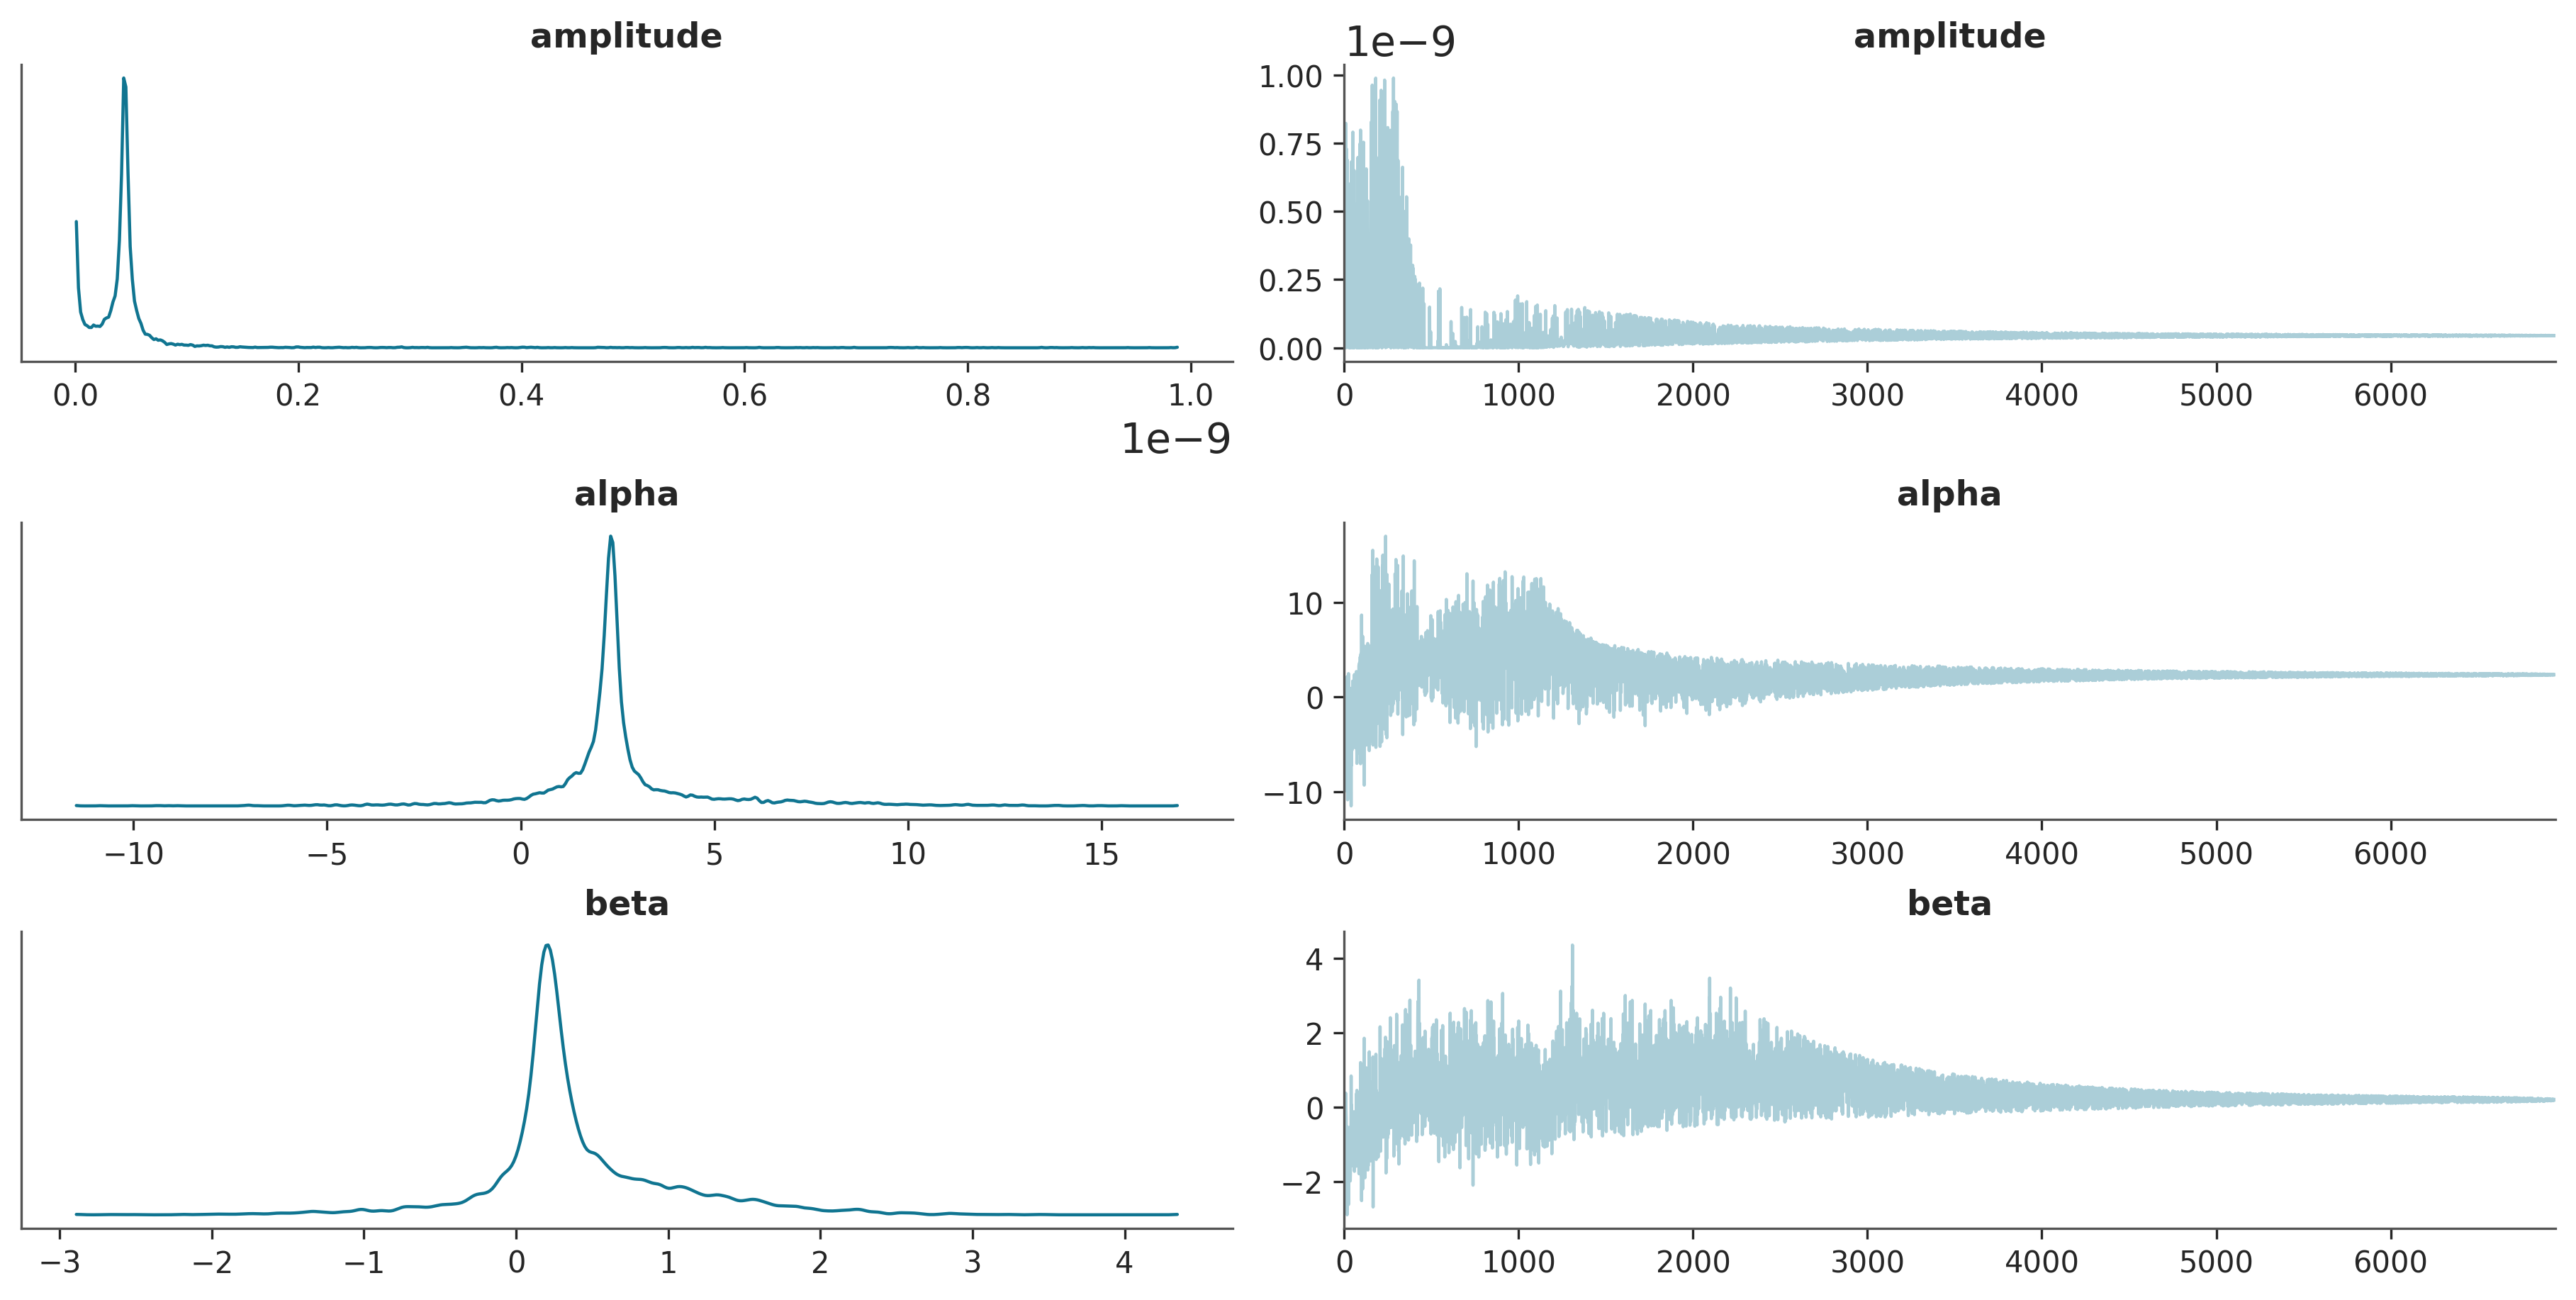

In [16]:
az.style.use("arviz-doc")

az.plot_trace(inference_data)
plt.show()

## Unweighted samples

In [17]:
# posterior_resampler
def resample_posterior(inference_data, n_samples=None, random_seed=42):
    """
    Resample posterior samples from an InferenceData object using importance weights.

    Parameters
    ----------
    inference_data : arviz.InferenceData
        The input InferenceData object with posterior and sample_stats["weights"].
    n_samples : int, optional
        Number of resampled draws. If None, use the number of original draws.
    random_seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    arviz.InferenceData
        A new InferenceData object with resampled posterior and sample_stats.
    """
    rng = np.random.default_rng(random_seed)

    # Extract posterior samples and weights
    posterior = inference_data.posterior
    weights = inference_data.sample_stats["weights"].values[0]  # shape: (draw,)
    weights = weights / weights.sum()  # normalize

    n_draws = posterior.sizes["draw"]
    n_samples = n_samples or n_draws

    # Resample indices
    resampled_idx = rng.choice(n_draws, size=n_samples, replace=True, p=weights)

    # Resample each group
    resampled_groups = {}
    for group in inference_data.groups():
        dataset = getattr(inference_data, group)
        if group == "prior":
            resampled_groups[group] = dataset
        else:
            resampled_data = {}
            for var in dataset.data_vars:
                values = dataset[var].values
                # Resample along draw dimension (axis=1)
                resampled_values = values[:, resampled_idx]
                resampled_data[var] = (["chain", "draw"], resampled_values)
            resampled_groups[group] = xr.Dataset(resampled_data)

    # Create new InferenceData with resampled groups
    return az.InferenceData(**resampled_groups)

In [18]:
# result_to_inference_data
def result_to_inference_data(
    results,
    datasets,
    n_prosterior_samples=None,
    n_prior_samples=None,
    random_seed=42,
    predictives=True,
):
    """
    Convert Sampler results to an ArviZ InferenceData object with optional resampling and prior inclusion.

    Parameters
    ----------
    results : gammapy.modeling.SamplerResult
        The sampler results and model informations.
    n_prosterior_samples : int, optional
        Number of samples to generate after resampling the posterior to take into account weights.
        Default is None, which use the unweighted samples from ultranest.
     n_prior_samples : int, optional
        If provided, generate this number of samples from the prior distribution using the model's
        prior transform and include them in the 'prior' group of the InferenceData.
    random_seed : int, optional
        Seed for reproducibility when resampling posterior or generating prior samples.
    predictives : bool, optional
        If True computes predicted counts and pointwise likelihood matrix. Defalut is True.

    Returns
    -------
    arviz.InferenceData
        An InferenceData object containing posterior samples, optionally resampled,
        prior samples (if requested), and log-evidence attributes ('logz' and 'logzerr').
    """

    sampler_results = results.sampler_results
    if n_prosterior_samples is None:
        inference_data = inference_data_from_ultranest(sampler_results)
    else:
        inference_data = inference_data_from_ultranest(sampler_results, weighted=True)
        inference_data = resample_posterior(
            inference_data, n_samples=n_prosterior_samples, random_seed=random_seed
        )  # unweighting

    # Add prior  group
    if n_prior_samples is not None:
        add_prior_samples(inference_data, results, n_prior_samples, random_seed)
        if predictives:
            add_sample_wise_quantities(inference_data, results, datasets, "prior")

    # Add posterior and log likelihood groups
    if predictives:
        add_sample_wise_quantities(inference_data, results, datasets, "posterior")
    return inference_data


def generate_prior_samples(parameters, n_prior_samples=1000, random_seed=42):
    """Generate prior samples. This function draws samples from the prior distributions of the model
    parameters using inverse transform sampling.

    Parameters
    ----------
    parameters : list
        The list of model parameters with priors to sample.
    n_prior_samples : int, optional
        Number of prior samples to generate. If None, no samples are added.
    random_seed : int, optional
        Seed for the random number generator to ensure reproducibility.
    """

    def _prior_inverse_cdf(values):
        """Returns a list of model parameters for a given list of values (that are bound in [0,1])."""
        if None in parameters:
            raise ValueError(
                "Some parameters have no prior set. You need priors on all parameters."
            )
        return [par.prior._inverse_cdf(val) for par, val in zip(parameters, values)]

    # Generate uniform samples in unit cube
    rng = np.random.default_rng(random_seed)
    unit_cube_samples = rng.uniform(size=(n_prior_samples, len(parameters)))

    # Transform to physical space using the prior transform
    prior_samples = np.array([_prior_inverse_cdf(u) for u in unit_cube_samples])
    return prior_samples


def add_prior_samples(inference_data, results, n_prior_samples=None, random_seed=42):
    """
    Generate and add prior samples to an ArviZ InferenceData object.

    This function draws samples from the prior distributions of the model
    parameters using inverse transform sampling. The samples are added to
    the `prior` group of the provided `InferenceData` object.

    Parameters
    ----------
    inference_data : `arviz.InferenceData`
        The inference data object to which the prior samples will be added.
    results : `SamplerResult`
        The sampler result object containing the model and its priors.
    n_prior_samples : int, optional
        Number of prior samples to generate. If None, no samples are added.
    random_seed : int, optional
        Seed for the random number generator to ensure reproducibility.

    Raises
    ------
    ValueError
        If any model parameter does not have a prior defined.
    """

    parameters = results.models.parameters.free_unique_parameters
    prior_samples = generate_prior_samples(parameters, n_prior_samples, random_seed)

    # Create prior group
    prior = xr.Dataset(
        {
            name: (["chain", "draw"], prior_samples[:, i][np.newaxis, :])
            for i, name in enumerate(parameters.names)
        }
    )
    inference_data.add_groups(prior=prior)


def add_sample_wise_quantities(inference_data, results, datasets, group_name):
    """
    Compute sample-wise quantities such as log-likelihood, log-prior, and predicted counts.

    This function evaluates the model for each sample in the specified group
    (posterior or prior) and computes the corresponding log-likelihood,
    log-prior, and predicted counts. These are added to the `InferenceData`
    object under appropriate groups.

    Parameters
    ----------
    inference_data : `arviz.InferenceData`
        The inference data object containing posterior or prior samples.
    results : `SamplerResult`
        The sampler result object containing the model and its parameters.
    datasets : `Datasets`
        The datasets used for computing likelihood and predictions.
    group_name : {"posterior", "prior"}
        The group of samples to evaluate.

    Notes
    -----
    - Assumes that the `stat_array()` method returns `-2 * log-likelihood`.
    - The function modifies the `InferenceData` object in-place.
    """

    group = getattr(inference_data, group_name)
    n_samples = group.sizes["draw"]
    log_likelihood_matrix = []
    log_prior_matrix = []
    npred_matrix = []
    with datasets.models.parameters.restore_status():
        for idx in range(
            n_samples
        ):  # this should be vectorialized, or parallelize or gammapy should dump stat_array on disk
            for p in datasets.models.parameters.free_parameters:
                p.value = group[p.name][0, idx].item()
            stat_array = (
                np.hstack([d.stat_array()[d.mask] for d in datasets]) / -2.0
            )  # assuming we have stat as -2lnL
            prior_stat_sum = (
                datasets.models.parameters.free_unique_parameters.prior_stat_sum()
                / -2.0
            )
            npred = np.hstack([d.npred().data[d.mask] for d in datasets])
            log_likelihood_matrix.append(stat_array)
            log_prior_matrix.append(prior_stat_sum)
            npred_matrix.append(npred)

        log_likelihood_matrix = np.array(log_likelihood_matrix)[np.newaxis, :, :]
        log_prior_matrix = np.array(log_prior_matrix)[np.newaxis, :]
        npred_matrix = np.array(npred_matrix)[np.newaxis, :, :]
        counts = np.hstack([d.counts.data[d.mask] for d in datasets])

    if group_name == "posterior":
        log_ligkelihood = xr.Dataset(
            {"log_ligkelihood": (["chain", "draw", "pixel"], log_likelihood_matrix)}
        )
        inference_data.add_groups(log_likelihood=log_ligkelihood)

        log_prior = xr.Dataset({"log_prior": (["chain", "draw"], log_prior_matrix)})
        inference_data.add_groups(log_prior=log_prior)

        posterior_predictive = xr.Dataset(
            {"counts": (["chain", "draw", "pixel"], npred_matrix)}
        )
        inference_data.add_groups(posterior_predictive=posterior_predictive)

        observed_data = xr.Dataset({"counts": (["pixel"], counts)})
        inference_data.add_groups(observed_data=observed_data)
    elif group_name == "prior":
        prior_predictive = xr.Dataset(
            {"counts": (["chain", "draw", "pixel"], npred_matrix)}
        )
        inference_data.add_groups(prior_predictive=prior_predictive)

In [19]:
print(result_joint.sampler_results["samples"].shape)
print(result_joint.sampler_results["weighted_samples"]["weights"].shape)

(6946, 3)
(6946,)


In [20]:
len(np.unique(result_joint.sampler_results["samples"][:, 1]))

2786

In [21]:
unique_ratio = len(np.unique(result_joint.sampler_results["samples"][:, 1])) / len(
    result_joint.sampler_results["samples"][:, 1]
)
unique_ratio

0.40109415490930034

In [22]:
unweighted_inference_data = inference_data_from_ultranest(
    result_joint.sampler_results, weighted=False
)

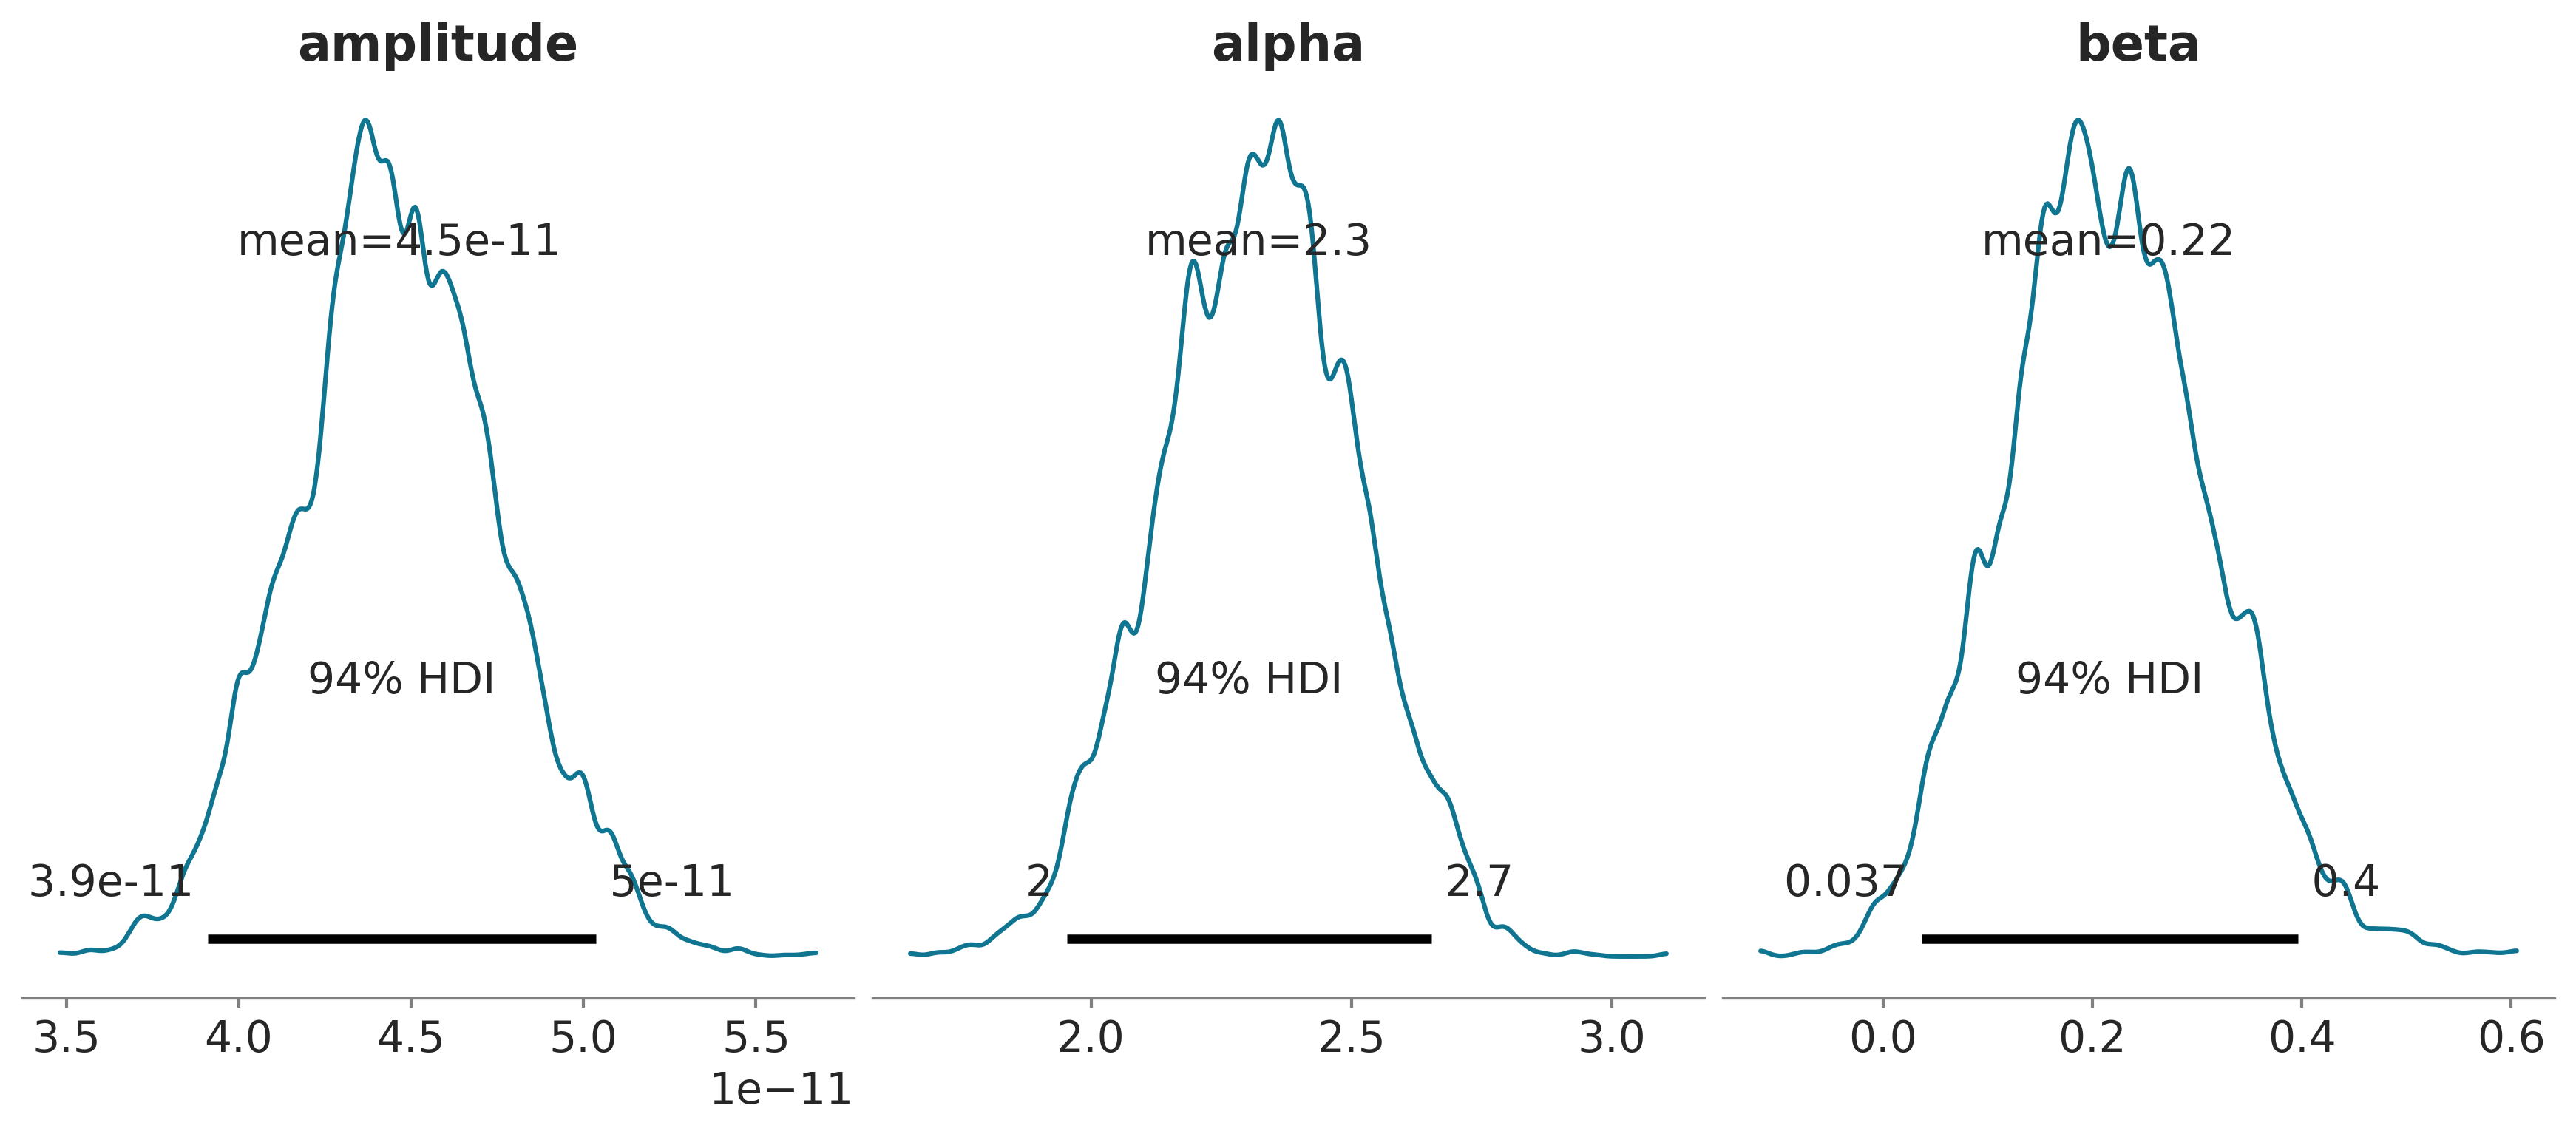

In [23]:
axes = az.plot_posterior(
    unweighted_inference_data,
    figsize=(11.5, 5),
)

fig = axes.flatten()[0].get_figure()

plt.show()

Let's do a random subsampling of the posterior. With less samples we have less repetitions and so less fluctuations but still enough for the distribution to be smooth. With less samples the predictives computations will aslo be faster.

In [24]:
n_samples_redu = int(
    np.sum(result_joint.sampler_results["weighted_samples"]["weights"] > 0) / 4
)
n_samples_redu

1631

In [25]:
# unweighted_inference_data = result_to_inference_data(result_joint, datasets, n_prosterior_samples=None, n_prior_samples=1000, predictives=False)
unweighted_inference_data = result_to_inference_data(
    result_joint, datasets, n_prosterior_samples=n_samples_redu, n_prior_samples=1000
)
unweighted_inference_data

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> log_prior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> unconstrained_posterior

In [26]:
unique_ratio = (
    len(np.unique(unweighted_inference_data.posterior["amplitude"])) / n_samples_redu
)
unique_ratio

0.7394236664622931

In [27]:
plot_prior = False
if plot_prior:
    axes = az.plot_posterior(
        unweighted_inference_data, figsize=(11.5, 5), group="prior"
    )

    fig = axes.flatten()[0].get_figure()

    plt.show()

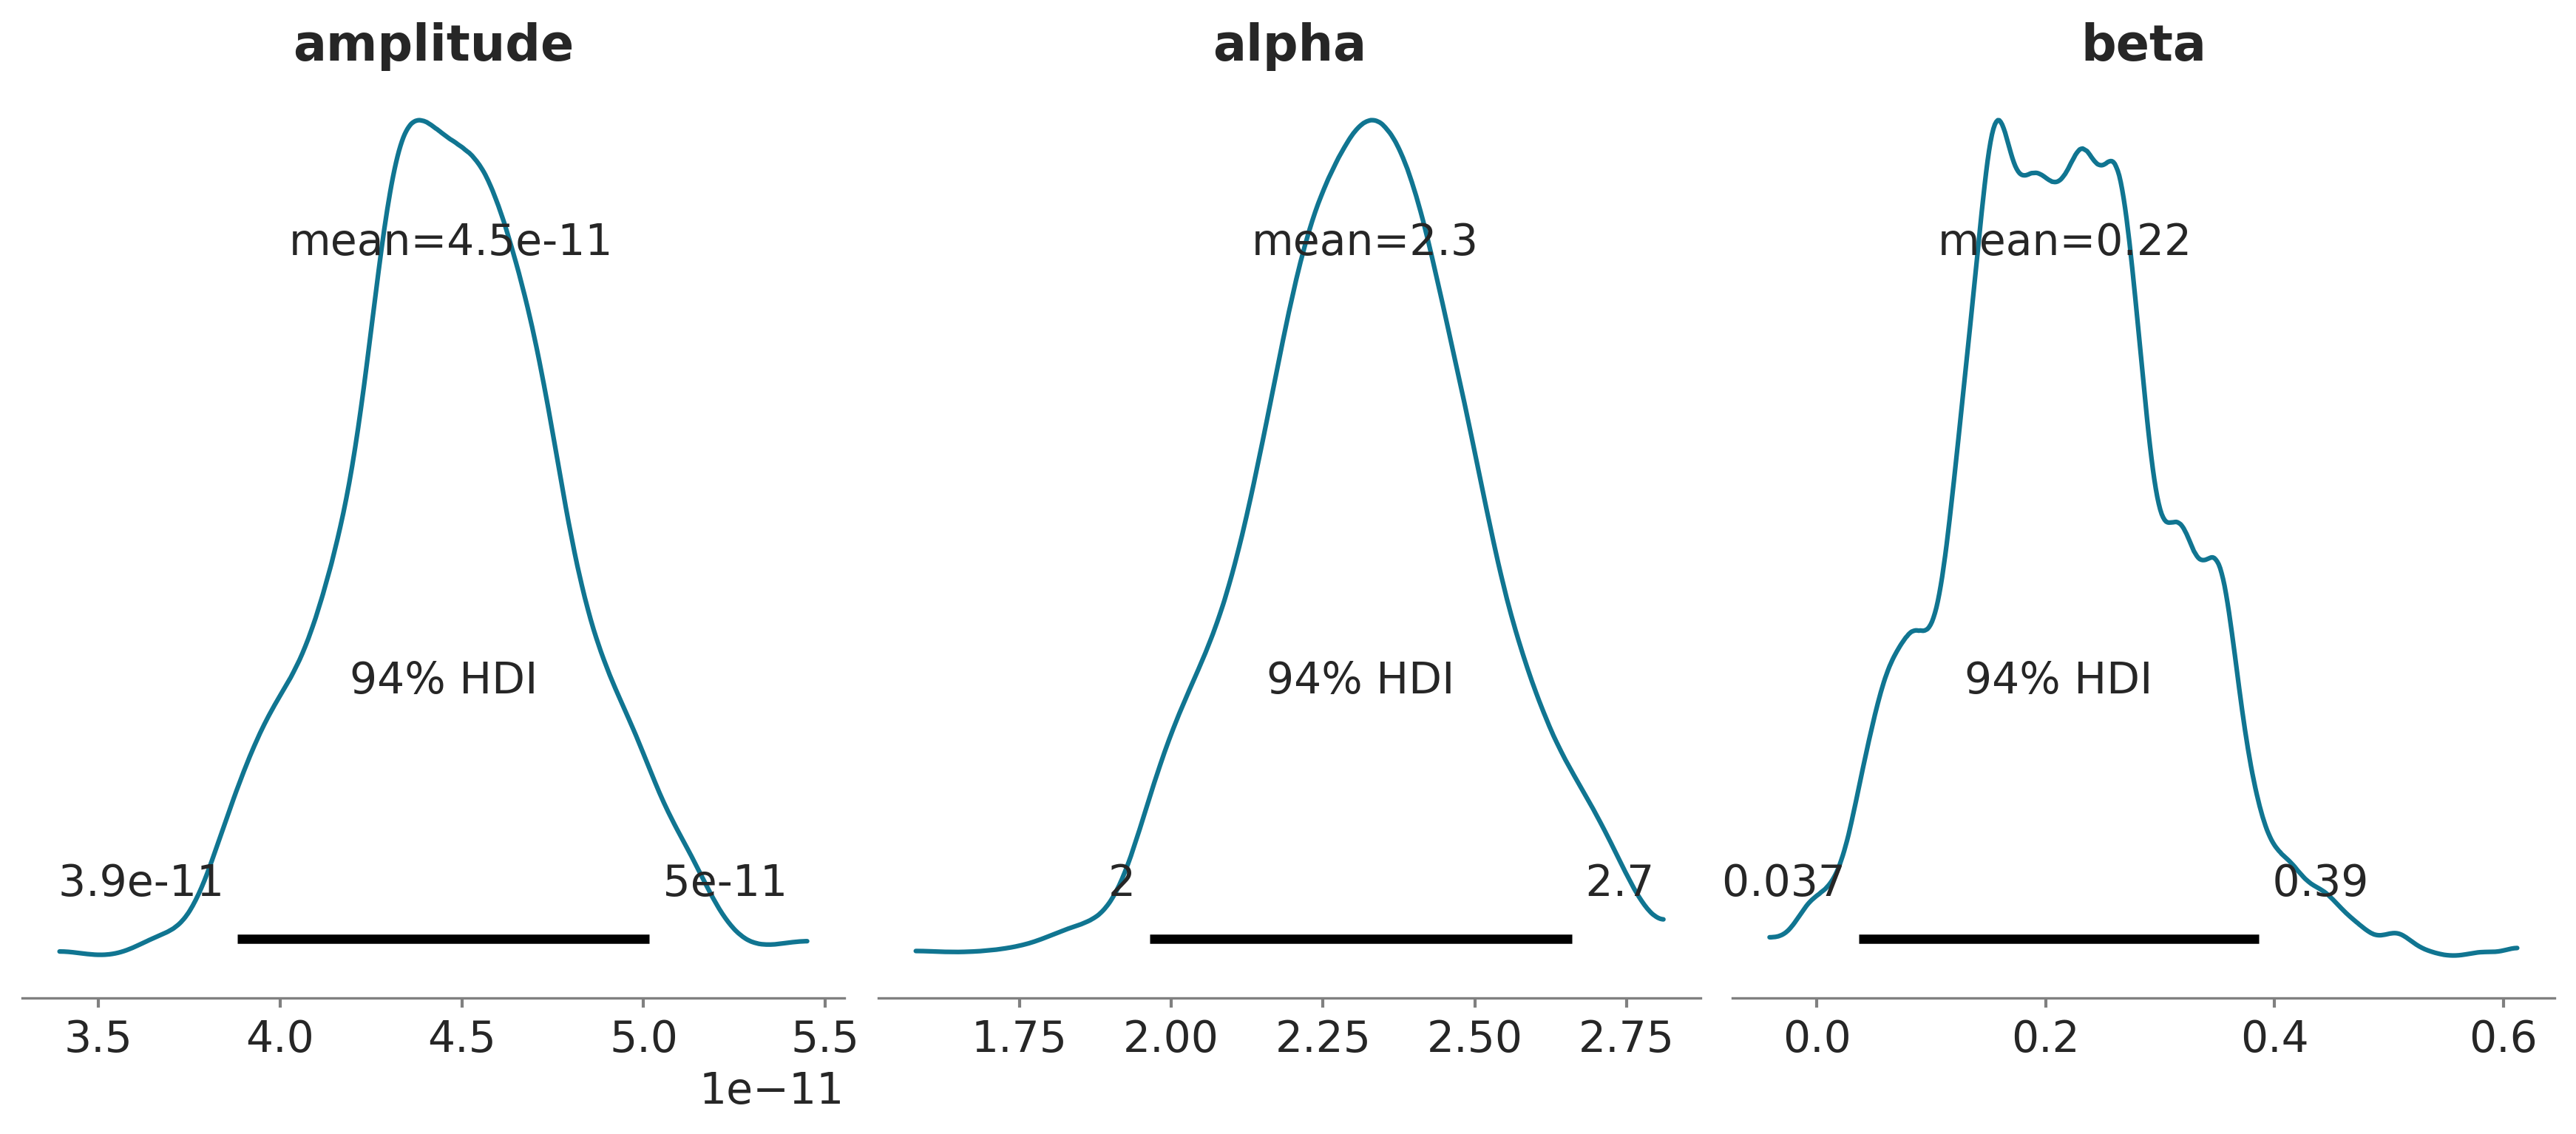

In [28]:
axes = az.plot_posterior(
    unweighted_inference_data,
    figsize=(11.5, 5),
)

fig = axes.flatten()[0].get_figure()

plt.show()

## Corner plot



/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/plots/pairplot.py:229: UserWarning: Divergences data not found, plotting without divergences. Make sure the sample method provides divergences data and that it is present in the `diverging` field of `sample_stats` or `sample_stats_prior` or set divergences=False
  warnings.warn(


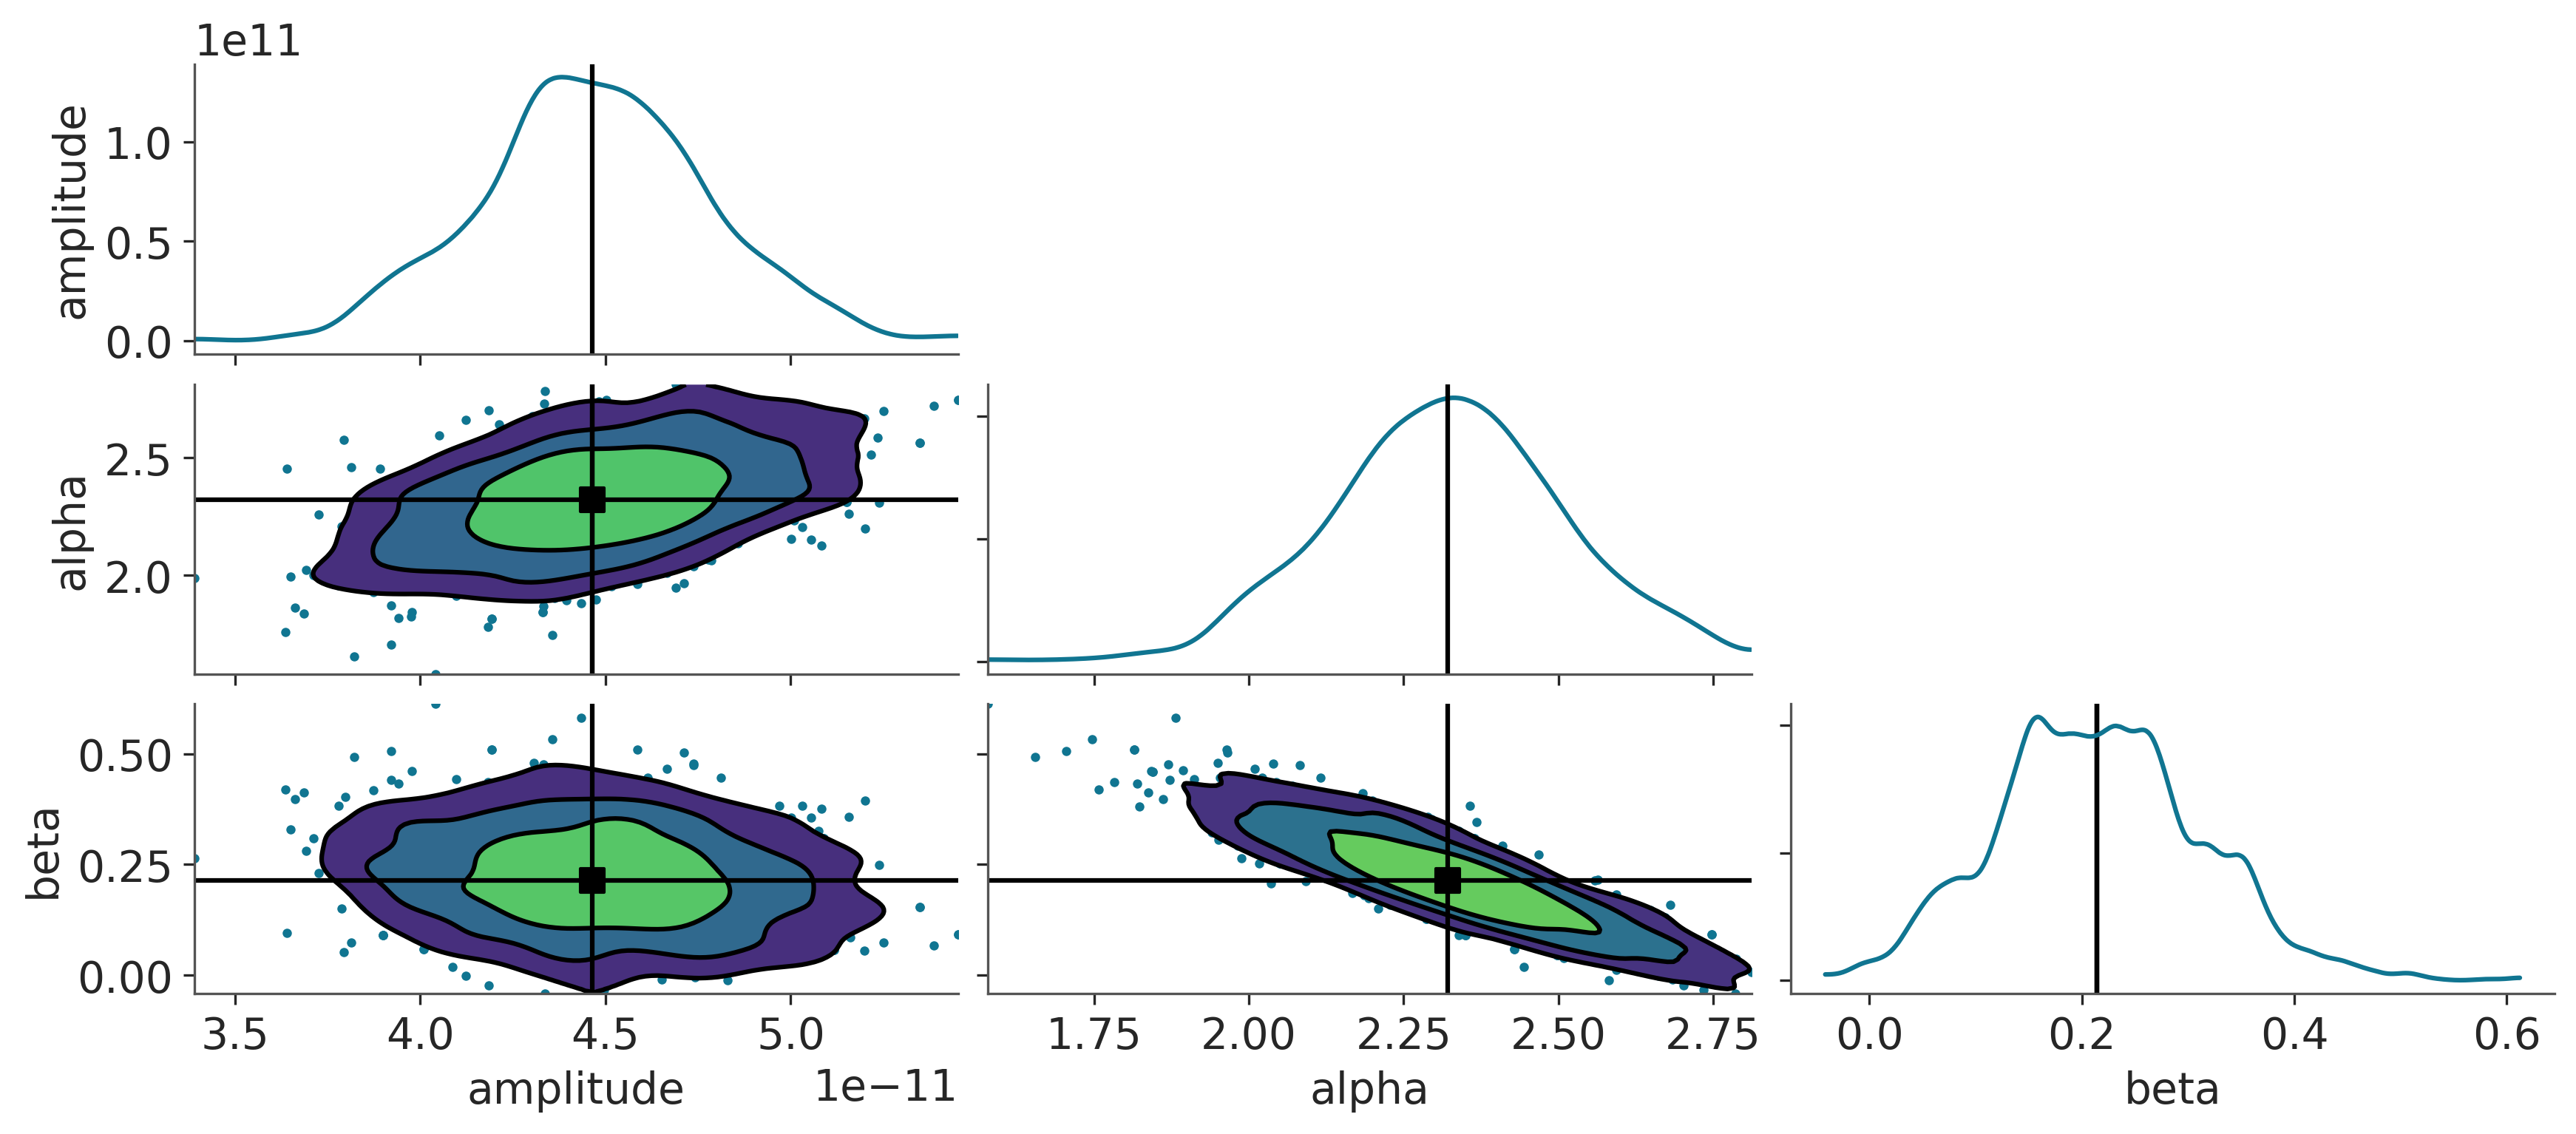

In [29]:
ax = az.plot_pair(
    unweighted_inference_data,
    kind=["scatter", "kde"],
    kde_kwargs={"fill_last": False},
    marginals=True,
    colorbar=True,
    divergences=True,
    point_estimate="median",
    figsize=(11.5, 5),
)

### Prior and posterior cumulated predictive distributions

(0.0, 30.0)

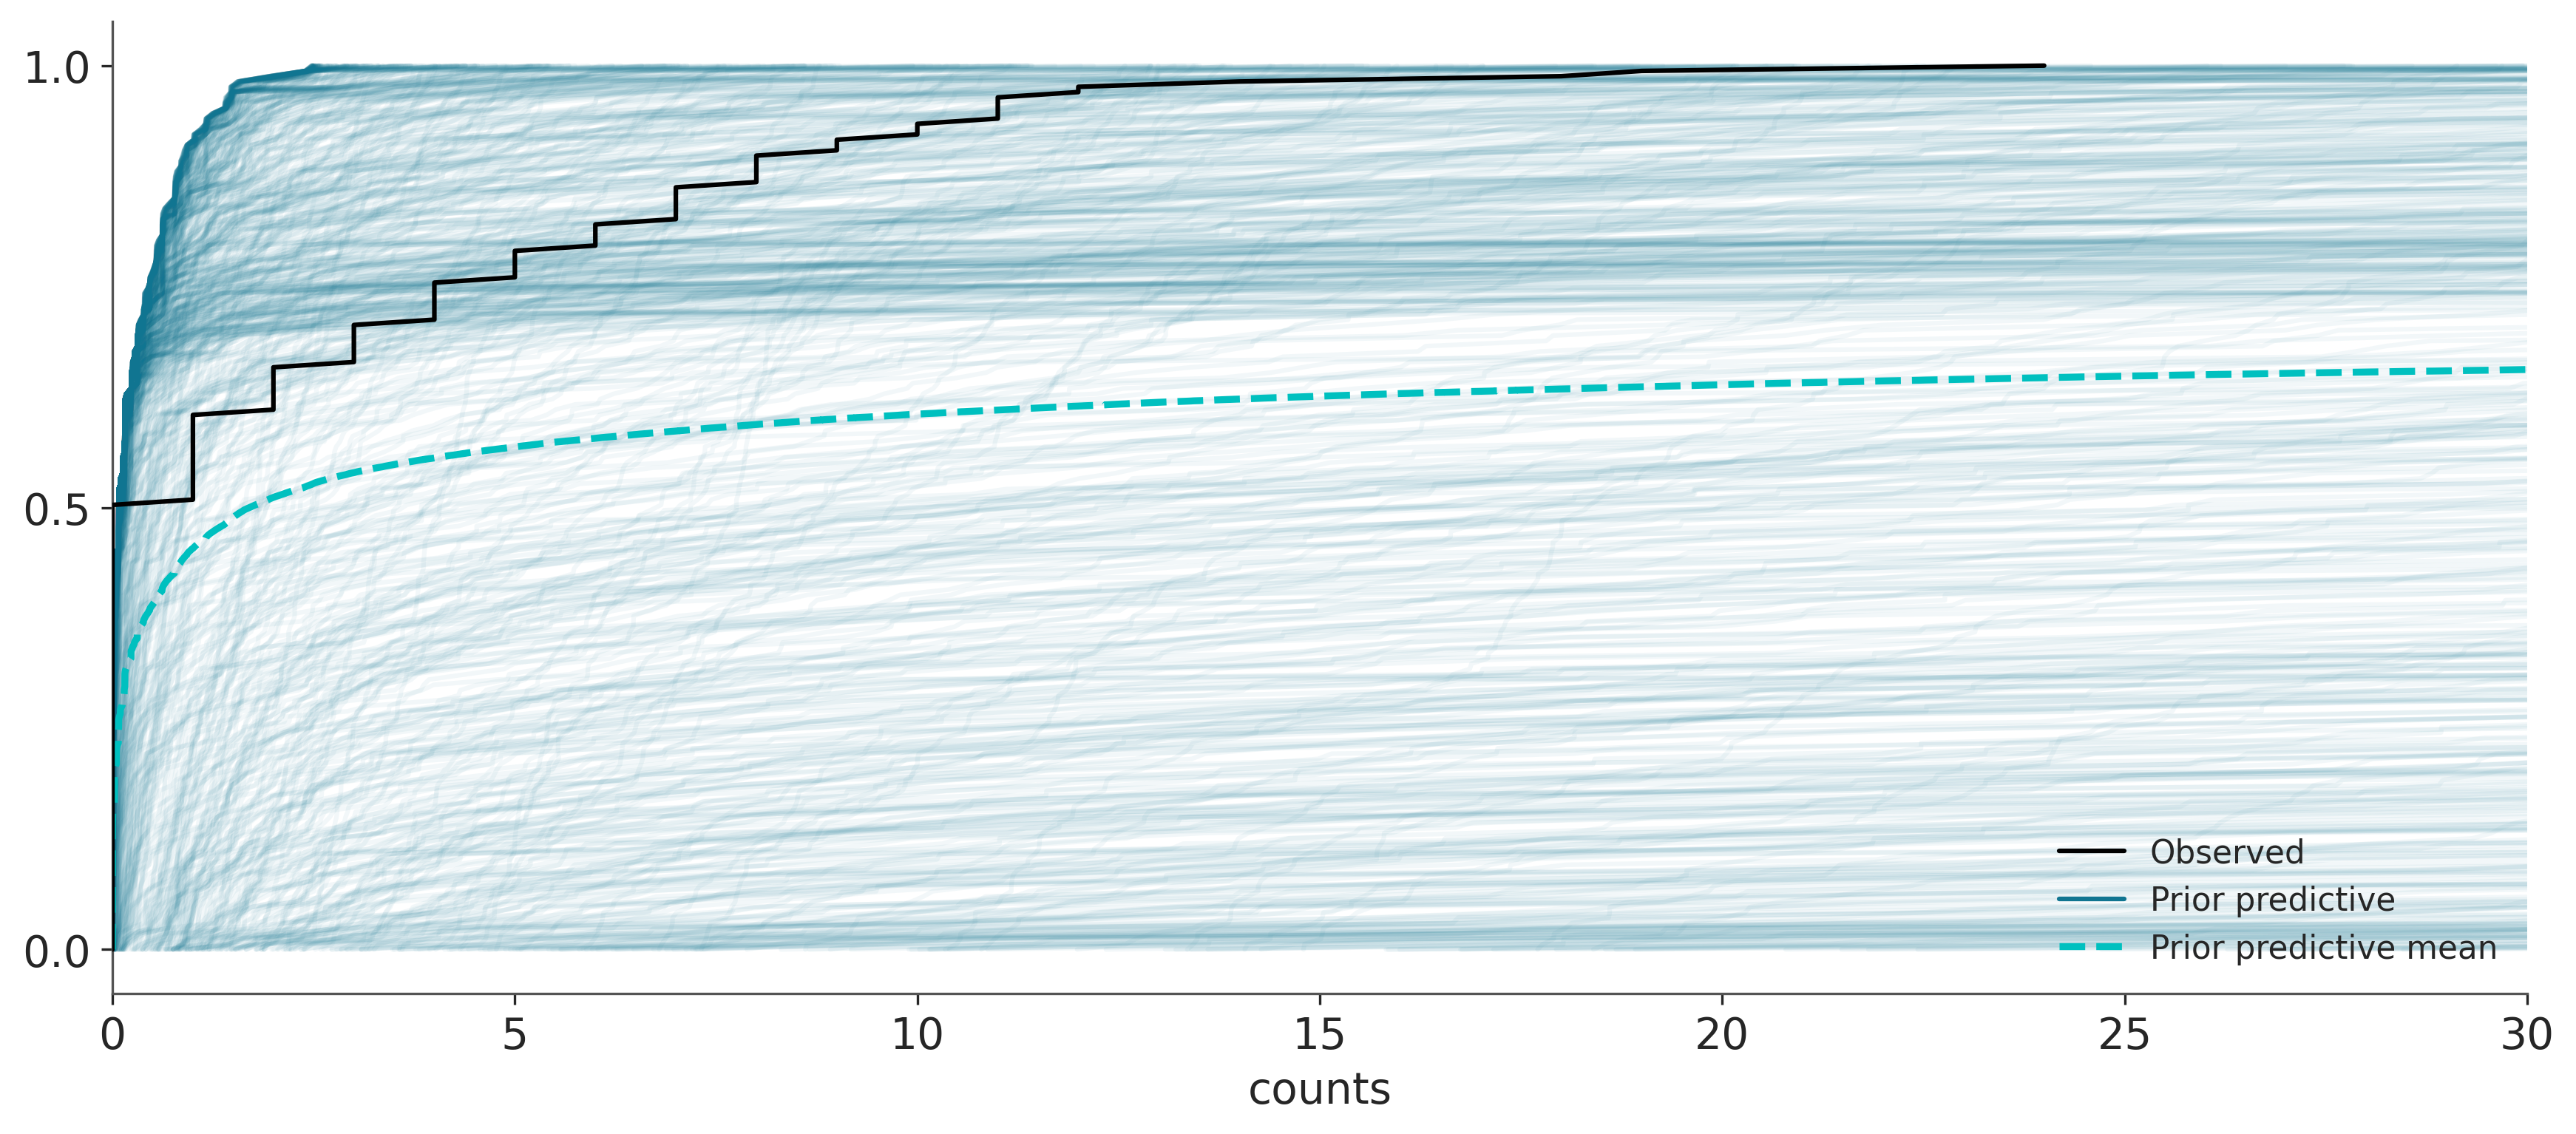

In [30]:
az.plot_ppc(
    unweighted_inference_data,
    alpha=0.05,
    kind="cumulative",
    textsize=14,
    group="prior",
    observed=True,
)
plt.xlim([0, 30])

<Axes: xlabel='counts'>

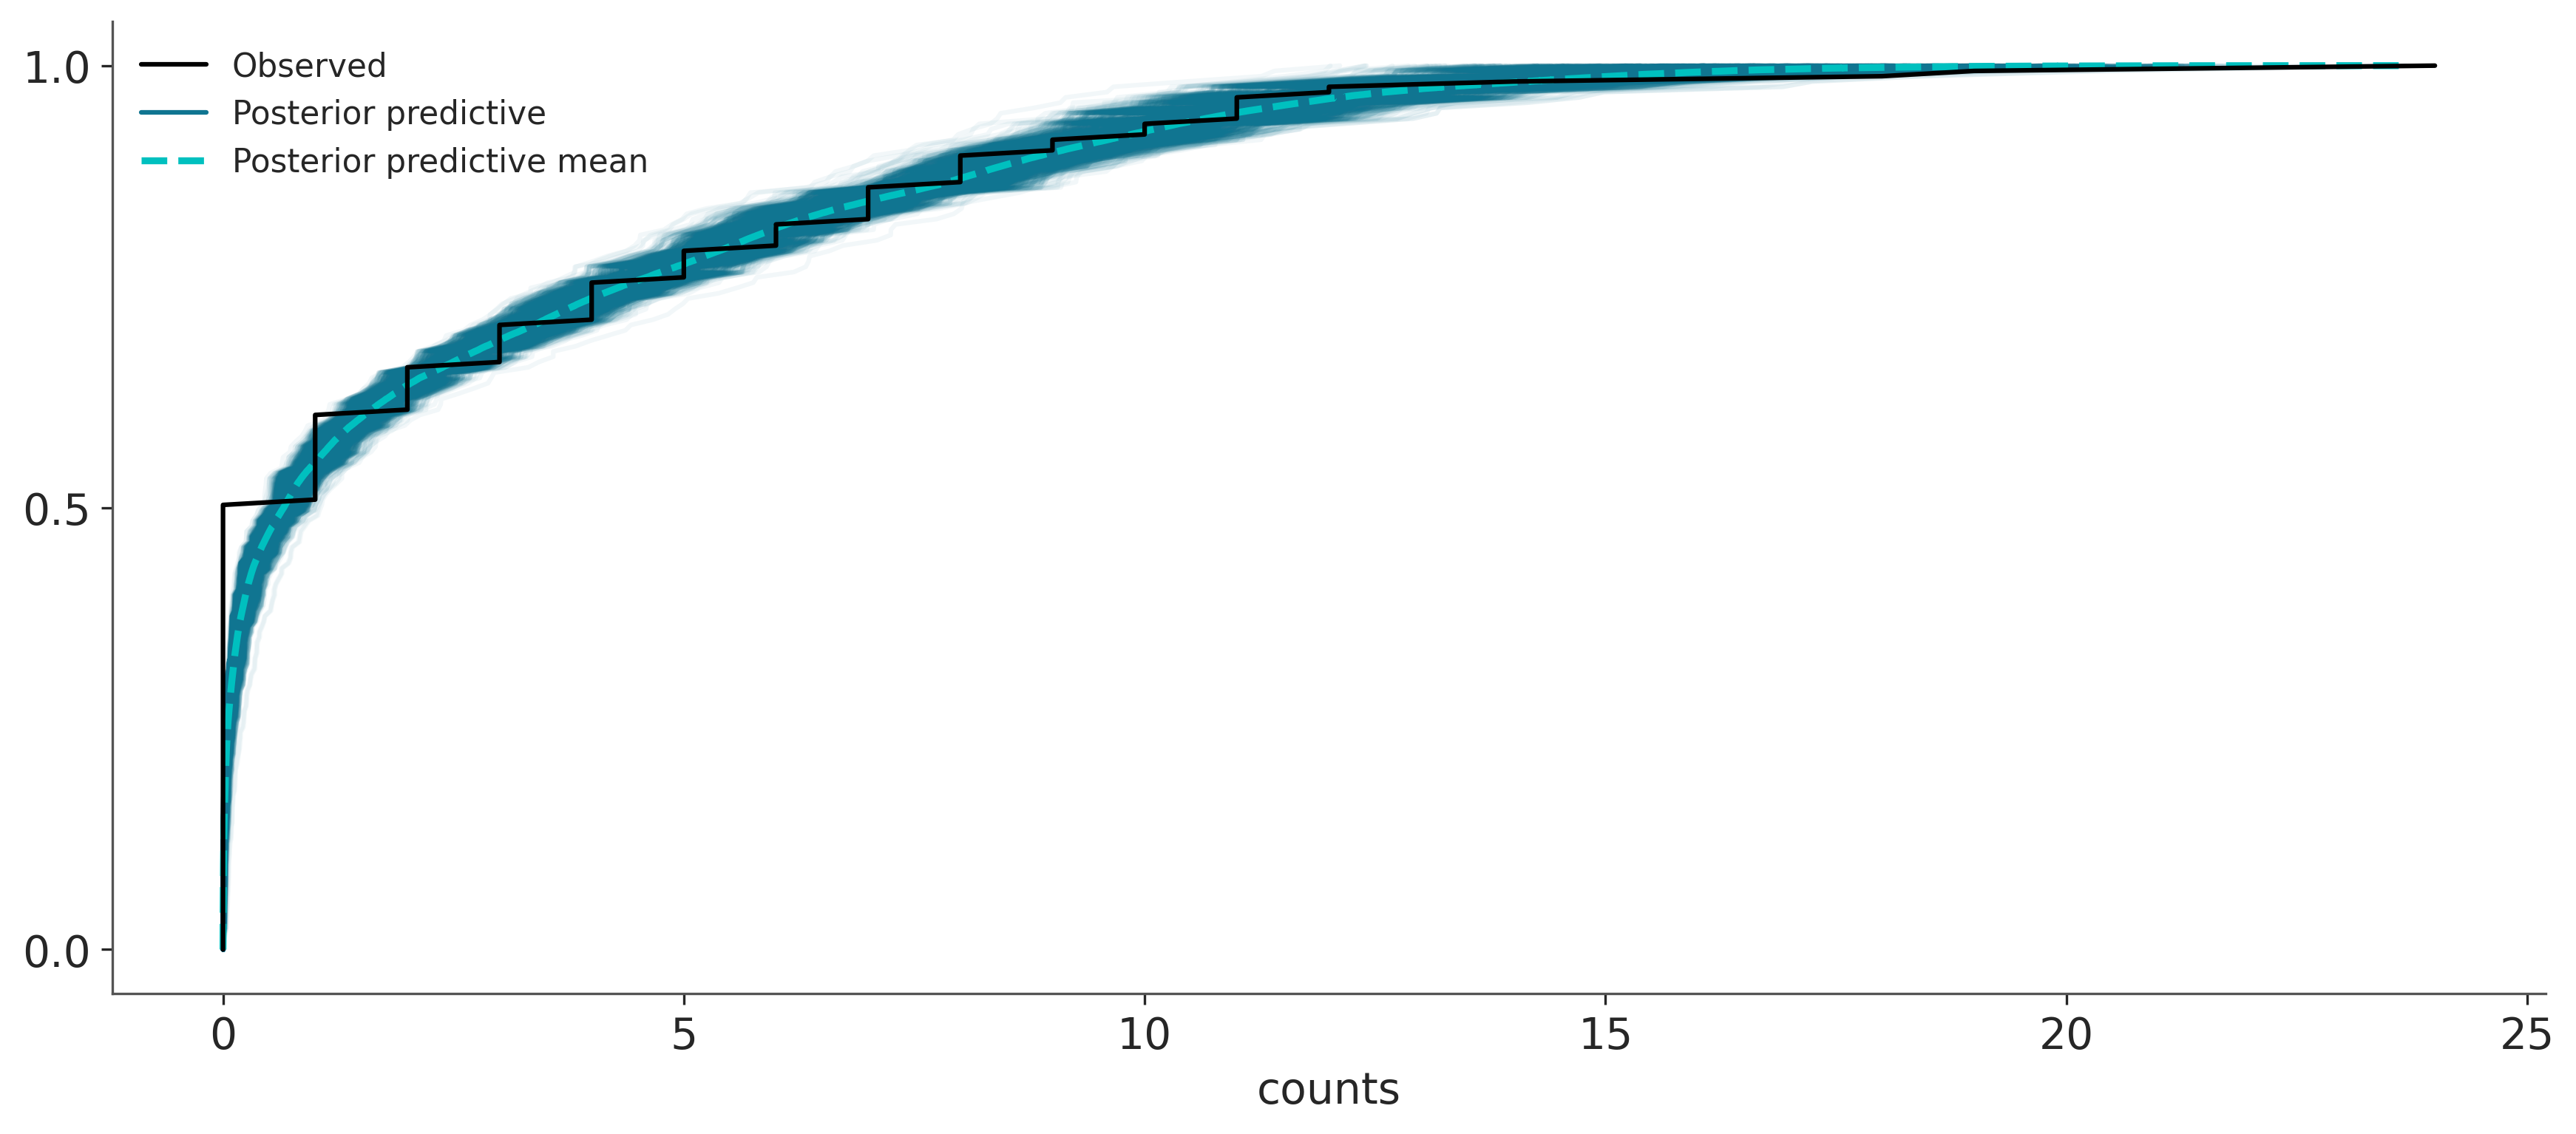

In [31]:
az.plot_ppc(
    unweighted_inference_data,
    alpha=0.05,
    kind="cumulative",
    textsize=14,
    group="posterior",
    observed=True,
)

### log_likelihood and log_prior ebaluated at posterior samples

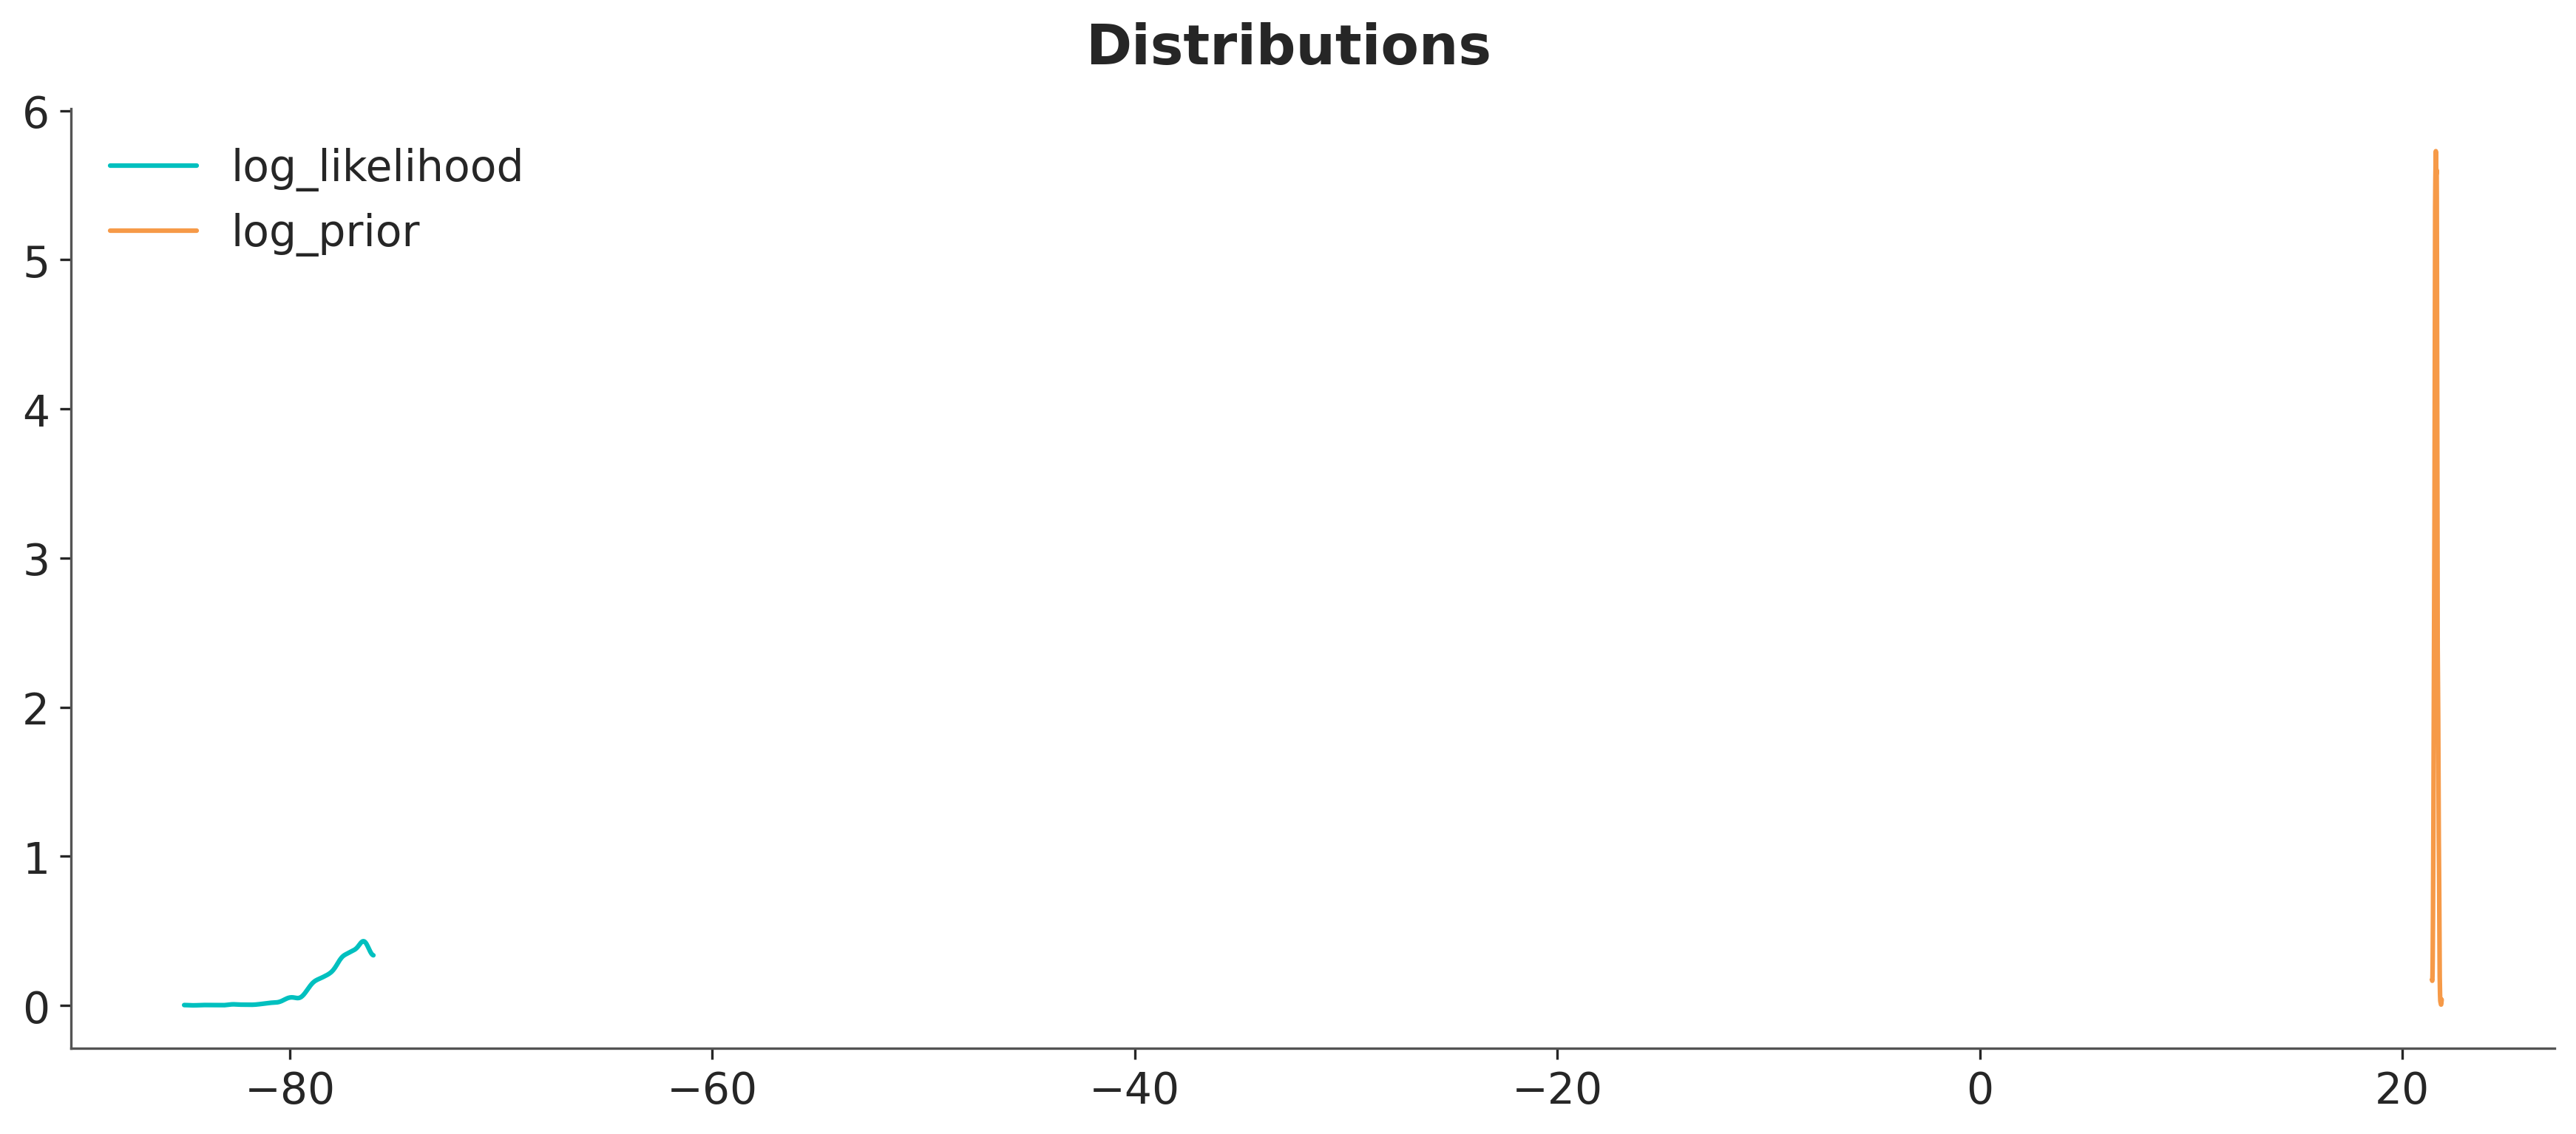

In [32]:
fig, ax = plt.subplots(1, 1)
fig.suptitle("Distributions")

az.plot_dist(
    unweighted_inference_data.sample_stats.log_likelihood.data,
    color="C1",
    label="log_likelihood",
)
az.plot_dist(
    unweighted_inference_data.log_prior.to_array().data, color="C2", label="log_prior"
)  # not sure thy I need to array here

plt.show()

# Parameters values

Within a Bayesian analysis, the concept of best-fit has to be viewed
differently from what is done in a gradient descent fit.

The output of the Bayesian analysis is the posterior distribution and
there is no “best-fit” output.
One has to define, based on the posteriors, what we want to consider
as “best-fit” and several options are possible:
- mean
- median
- mode
- maximum likelihood value
 
Which value should we assign to the model ?

In [33]:
# comparison of mean, median, mode and maximum likelihood
from astropy.table import Table
from scipy.stats import gaussian_kde


def compute_parameters_values(inference_data, results, group_name="posterior"):
    """
    Compute summary statistics for model parameters from an InferenceData object.

    This function calculates the mean, median, mode, and (if available) the
    value at the maximum likelihood for each parameter in the specified group
    (posterior or prior). The mode is estimated using a Gaussian KDE.

    Parameters
    ----------
    inference_data : `arviz.InferenceData`
        The inference data object containing posterior or prior samples.
    results : `SamplerResult`
        The sampler result object containing maximum likelihood estimates.
    group_name : str, optional
        The group to extract parameters from. Can be "posterior" or "prior".

    Returns
    -------
    summary_table : `~astropy.table.Table`
        Table summarizing the mean, median, mode, and value at maximum likelihood
        (if available) for each parameter.
    """

    group = getattr(inference_data, group_name)
    maximum_likelihood = results.sampler_results["maximum_likelihood"]
    # could use inference_data and apply weight in calculations
    # for mean = np.sum(weights*samples)/np.sum(weights)
    # for median it's more compliated https://gist.github.com/robbibt/c7ec5f0cb3e4e0cee5ed3156bcb666de)
    # for mode use : kde = gaussian_kde(samples, weights=weights)
    # Prepare lists to store results
    param_names = []
    means = []
    medians = []
    modes = []
    maxlnl = []
    # Iterate over each parameter
    for k, var in enumerate(group.data_vars):
        samples = group[var].values.flatten()
        param_names.append(var)
        means.append(np.mean(samples))
        medians.append(np.median(samples))
        if group_name == "posterior":
            maxlnl.append(maximum_likelihood["point"][k])
        else:
            maxlnl.append(None)
        # Estimate mode using KDE
        kde = gaussian_kde(samples)
        x_vals = np.linspace(np.min(samples), np.max(samples), 1000)
        mode_val = x_vals[np.argmax(kde(x_vals))]
        modes.append(mode_val)

    summary_table = Table(
        [param_names, means, medians, modes, maxlnl],
        names=("parameter", "mean", "median", "mode", "value at max ln(L)"),
    )

    return summary_table


print("Prior")
display(
    compute_parameters_values(
        unweighted_inference_data, result_joint, group_name="prior"
    )
)

print("Posterior")
display(
    compute_parameters_values(
        unweighted_inference_data, result_joint, group_name="posterior"
    )
)

Prior


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,object
amplitude,1.077106805371913e-10,8.410176133999183e-12,1.0992373681659576e-11,None
alpha,2.6322603231992705,2.5216531968120597,2.335369830863007,None
beta,0.09431505298827156,0.10335383854099794,0.13496769595436975,None


Posterior


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,4.469578453240076e-11,4.465247482679691e-11,4.393531175088577e-11,4.484014974339152e-11
alpha,2.3192322526869193,2.3217289998251878,2.3303437237681806,2.3678489383565497
beta,0.21716046700715905,0.21455242933348567,0.22937025120238813,0.18414442093933064


# Information criterions
## Bayes Factor

Bayes factor can be used for model comparison of nested models, it increases if the model difference is more significative. \
Here we can see how much we gained between the prior and the posterior.

In [34]:
result_joint.models.parameters["alpha"].prior

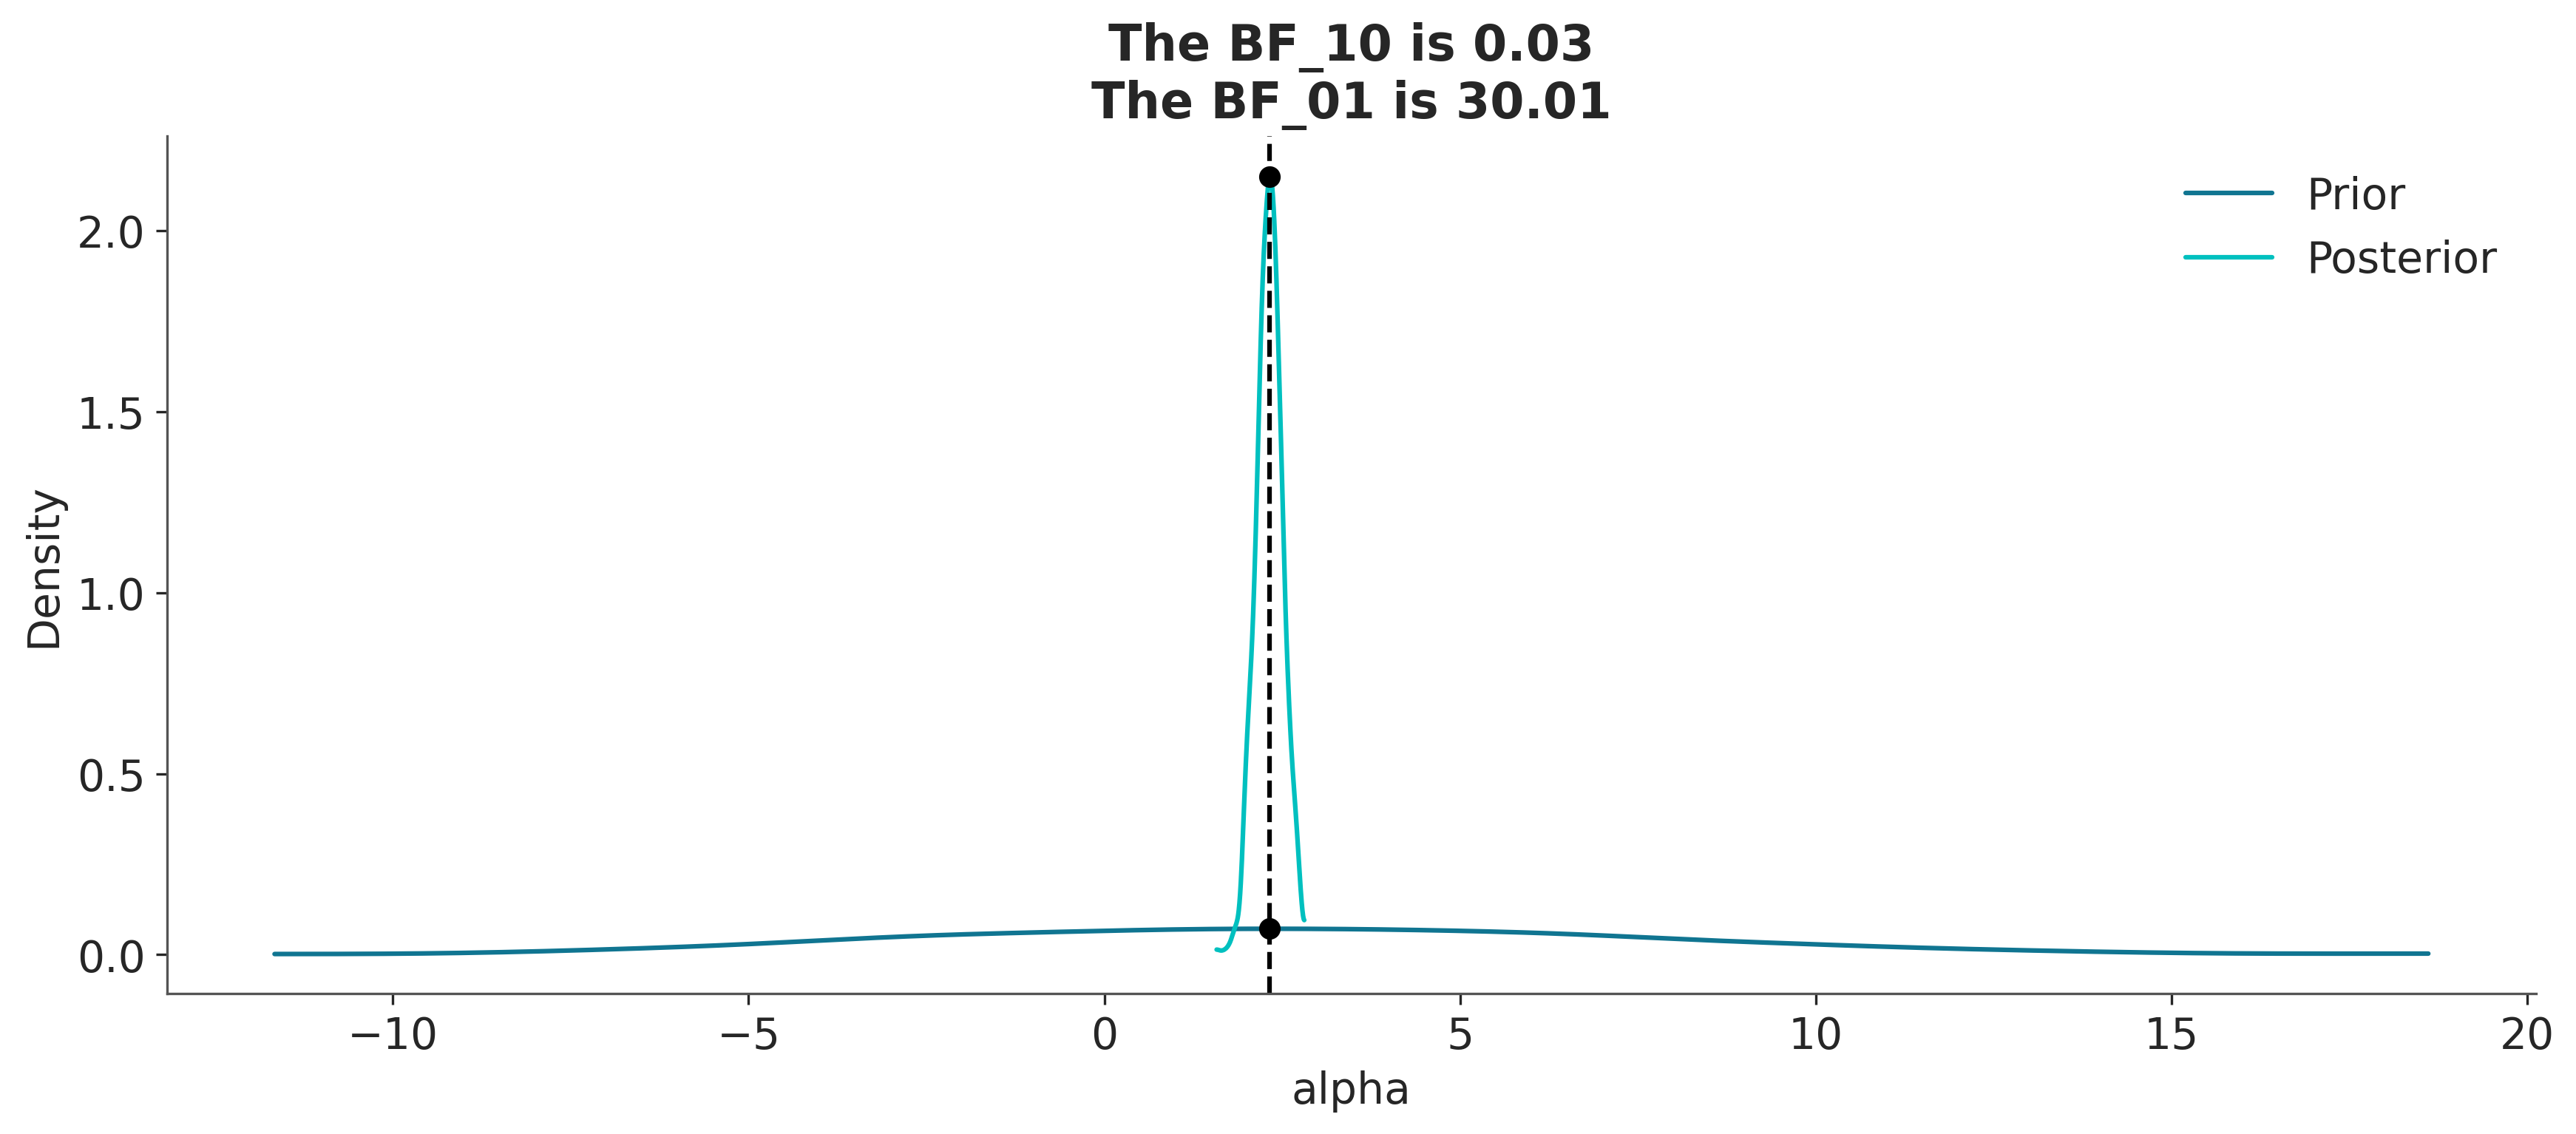

In [35]:
az.plot_bf(
    unweighted_inference_data,
    var_name="alpha",
    ref_val=result_joint.models.parameters["alpha"].value,
)
plt.show()

## ELPD : expected log-predictive density

The ELPD is a more Bayesian way to measure goodness of fit that the term used in AIC, but we are still missing one element, the penalization term, which is added in the following statistics.

Asymptotically tends to AIC.


### WAIC widely applicable information criterion

The Widely applicable information criterion (WAIC) uses the ELPD plus a penalization term [(Watanabe 2013)](https://arviz-devs.github.io/EABM/Chapters/References.html#ref-watanabe_2013).

In [36]:
elpd_waic = az.waic(unweighted_inference_data, scale="deviance")

print(elpd_waic)

Computed from 1631 posterior samples and 168 observations log-likelihood matrix.

              Estimate       SE
deviance_waic   159.36    18.59
p_waic            3.96        -

There has been a warning during the calculation. Please check the results.


/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


### PSIS-LOO-CV : Pareto-smoothed importance sampling leave-one-out cross-validation



Another way to add penalization on ELPD penalization is cross-validation.

One round of cross-validation involves partitioning a sample of data into complementary subsets, performing the analysis on one subset (called the training set), and validating the analysis on the other subset (called the validation set or testing set).
Leave-p-out cross-validation involves using p observations as the validation set and the remaining observations as the training set.
Leave-one-out cross-validation (LOOCV) is a particular case of leave-p-out cross-validation with p = 1.

One downside of cross-validation is that it is computationally expensive. We need to fit the model 
 times, and if we have a large dataset, this can be very expensive. But lucky us, by being Bayesian we can approximately compute LOO-CV in a very fast way unsing importance sampling. The method used here is the Pareto-Smooth Importance Sampling Leave-One-Out Cross Validation [(Vehtari, Gelman, and Gabry 2017; Yao et al. 2018)](https://arviz-devs.github.io/EABM/Chapters/References.html#ref-vehtari_2017), which is abbreviated as PSIS-LOO-CV


In [37]:
elpd_loo = az.loo(unweighted_inference_data, scale="deviance")
print(elpd_loo)

Computed from 1631 posterior samples and 168 observations log-likelihood matrix.

             Estimate       SE
deviance_loo   159.41    18.59
p_loo            3.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.69]   (good)      168  100.0%
   (0.69, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



The Pareto k diagnostic tell us if the approximation used to compute LOO is valid. In general ideally it should be lower than 0.7 in every pixel.

The p_loo/p_waic give us an estimate of the effective number of parameters. 

LOO should be more robust than WAIC.

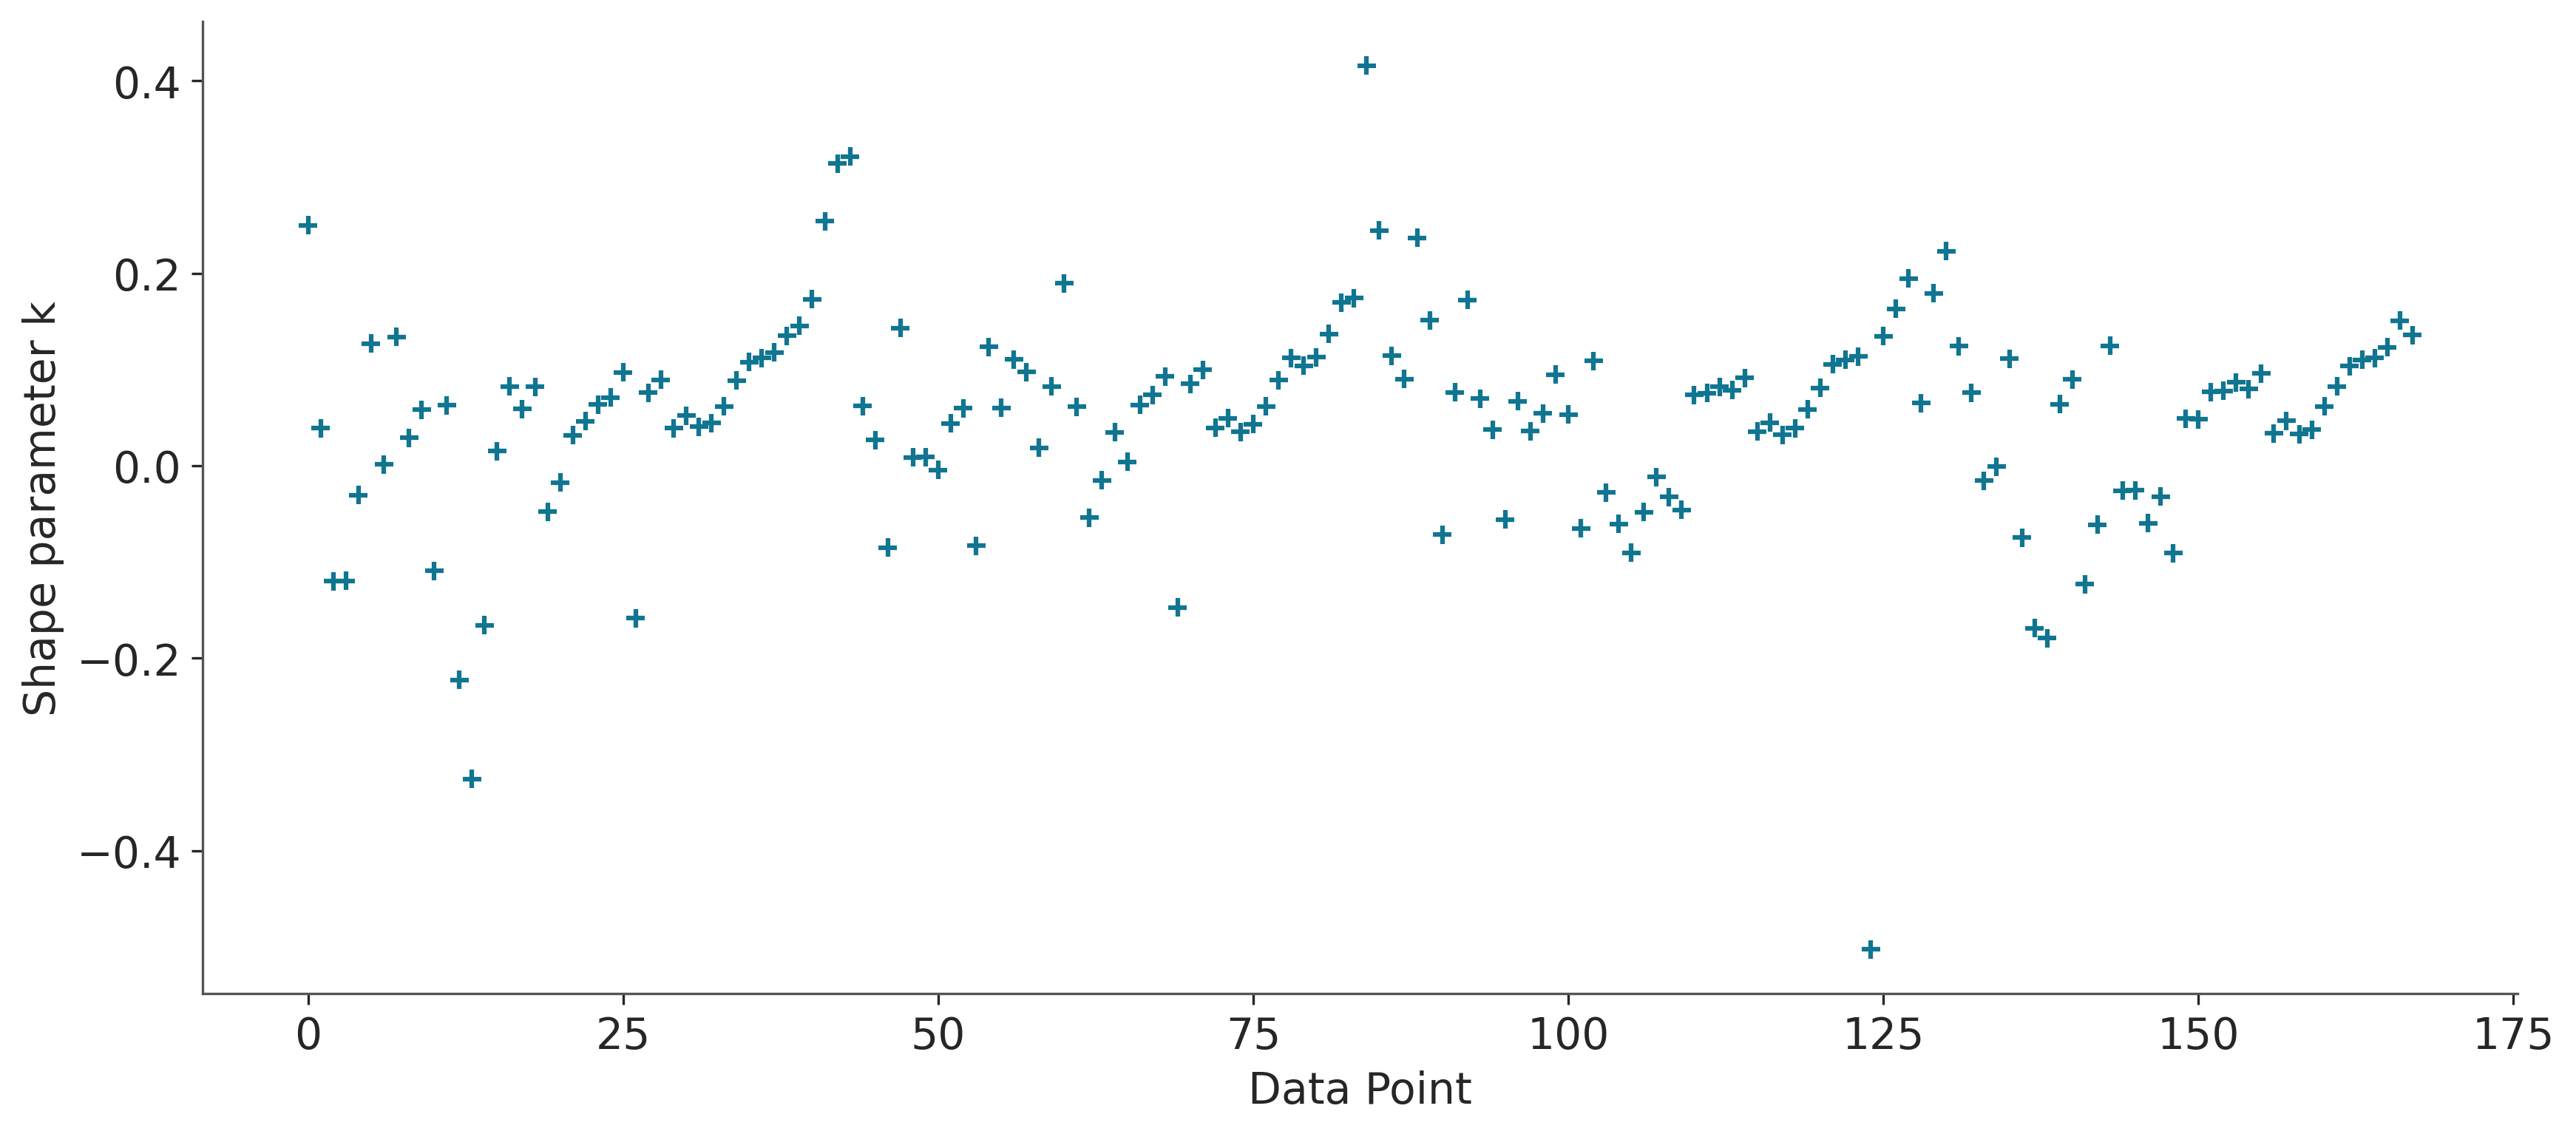

In [38]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_khat(elpd_loo)
plt.show()

### Summary stats table




In [39]:
# compare statistics
logz = result_joint.sampler_results["logz"]
logzerr = result_joint.sampler_results["logzerr"]
logl = result_joint.sampler_results["maximum_likelihood"]["logl"]
AIC = -2 * result_joint.sampler_results["maximum_likelihood"]["logl"] + 2 * len(
    result_joint.models.parameters.free_unique_parameters
)

print(
    "-2logZ       :",
    -2 * result_joint.sampler_results["logz"],
    "+/-",
    -2 * result_joint.sampler_results["logzerr"],
)
print("-2logL       :", -2 * result_joint.sampler_results["maximum_likelihood"]["logl"])
print(
    "AIC          :",
    -2 * result_joint.sampler_results["maximum_likelihood"]["logl"]
    + 2 * len(result_joint.models.parameters.free_unique_parameters),
)
print(
    "elpd_waic    :",
    elpd_waic.elpd_waic,
    "+/-",
    elpd_waic.se,
    ", effective dof",
    elpd_waic.p_waic,
)
print(
    "elpd_loo     :",
    elpd_loo.elpd_loo,
    "+/-",
    elpd_loo.se,
    ", effective dof",
    elpd_loo.p_loo,
)

-2logZ       : 173.581730695639 +/- -0.36466576545805734
-2logL       : 152.04861376840623
AIC          : 158.04861376840623
elpd_waic    : 159.35850661119804 +/- 18.585962248805657 , effective dof 3.9607929282251613
elpd_loo     : 159.41419891092994 +/- 18.594647727802773 , effective dof 3.9886390780911256


In [40]:
# Create an Astropy Table
summary_table = Table(
    [
        [f"{model_type} ({prior_type})"],
        [-2 * logz],
        [-2 * logl],
        [AIC],
        [elpd_waic.elpd_waic],
        [elpd_loo.elpd_loo],
        [elpd_waic.p_waic],
        [elpd_loo.p_loo],
        [logzerr],
        [elpd_waic.se],
        [elpd_loo.se],
    ],
    names=(
        "Model (prior)",
        "logz",
        "ln(L)",
        "AIC",
        "elpd (waic)",
        "elpd (loo)",
        "waic eff. dof",
        "loo eff. dof",
        "logz error",
        "elpd error (waic)",
        "elpd error (loo)",
    ),
)

# Display the table
display(summary_table)

Model (prior),logz,ln(L),AIC,elpd (waic),elpd (loo),waic eff. dof,loo eff. dof,logz error,elpd error (waic),elpd error (loo)
str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
lp (diffuse),173.581730695639,152.04861376840623,158.04861376840623,159.35850661119804,159.41419891092994,3.9607929282251613,3.9886390780911256,0.18233288272902867,18.585962248805657,18.594647727802773


# Model comparion

When comparing models of different degree of freedom how the relative strengh of prior affects the comparion for the different information criterion ?

## New Bayesian model selection class

In [41]:
# combine all of this together in few new classes
from astropy.table import vstack, Column
import arviz.preview as azp


class BayesianModelSelection:
    """
    Run Bayesian inference for a set of alternative models.

    Parameters
    ----------
    datasets : `Datasets`
        The datasets on which to perform the model fitting.
    alternative_models : dict
        Dictionary of model names and corresponding `Models` objects.

    Returns
    -------
    result : `BayesianModelSelectionResult`
        Object containing the results of the model comparisons.
    """

    def __init__(self, sampler, prosterior_reduction_factor=4, n_prior_samples=1000):
        self.sampler = sampler
        self.prosterior_reduction_factor = prosterior_reduction_factor
        self.n_prior_samples = n_prior_samples

    def run(self, datasets, alternative_models):
        results = {}
        for models_name, models in alternative_models.items():
            print(f"Evaluating {models_name}")
            datasets.models = models
            sampler_results = self.sampler.run(datasets)
            results[models_name] = ExtendedSamplerResult(
                models_name,
                sampler_results,
                datasets,
                self.prosterior_reduction_factor,
                self.n_prior_samples,
            )
            display(results[models_name].parameters_table())
            print(results[models_name])
        return BayesianModelSelectionResult(results)


class ExtendedSamplerResult:
    """
    Container for the results of a Bayesian model fit.

    Stores the sampler output, inference data, and computed statistics
    for a given model.

    Parameters
    ----------
    models_name : str
        Name of the model.
    sampler_results : `SamplerResult`
        Output from the sampler run.
    datasets : `Datasets`
        The datasets used for the fit.
    prosterior_reduction_factor : int, optional
        Factor to reduce posterior samples for efficiency.
    n_prior_samples : int, optional
        Number of prior samples to generate.
    """

    def __init__(
        self,
        models_name,
        sampler_results,
        datasets,
        prosterior_reduction_factor=4,
        n_prior_samples=1000,
    ):
        self._models_name = models_name
        self._models = sampler_results.models
        self._sampler_results = sampler_results.sampler_results
        if prosterior_reduction_factor > 1:
            n_samples_redu = int(
                np.sum(
                    sampler_results.sampler_results["weighted_samples"]["weights"] > 0
                )
                / prosterior_reduction_factor
            )
        else:
            n_samples_redu = None
        self._unweighted_inference_data = result_to_inference_data(
            sampler_results,
            datasets,
            n_prosterior_samples=n_samples_redu,
            n_prior_samples=n_prior_samples,
        )
        self._parameters_table = compute_parameters_values(
            self._unweighted_inference_data, sampler_results, group_name="posterior"
        )
        if n_prior_samples is not None:
            self._parameters_table_prior = compute_parameters_values(
                self._unweighted_inference_data, sampler_results, group_name="prior"
            )
        self._elpd_waic = az.waic(self._unweighted_inference_data, scale="deviance")
        self._elpd_loo = az.loo(self._unweighted_inference_data, scale="deviance")

    @property
    def models(self):
        return self._models

    @property
    def models_name(self):
        return self._models_name

    @property
    def sampler_results(self):
        """Sampler results dictionary."""
        return self._sampler_results

    @property
    def unweighted_inference_data(self):
        """ArviZ `InferenceData` object with unweighted posterior samples."""
        return self._unweighted_inference_data

    @property
    def dof(self):
        """Number of free unique parameters (degrees of freedom)."""
        return len(self.models.parameters.free_unique_parameters)

    @property
    def logz(self):
        """Log-evidence (logZ) from the sampler."""
        return self.sampler_results["logz"]

    @property
    def logz_err(self):
        """Uncertainty on the log-evidence."""
        return self.sampler_results["logzerr"]

    @property
    def logl(self):
        """Maximum log-likelihood value."""
        return self.sampler_results["maximum_likelihood"]["logl"]

    @property
    def aic(self):
        """Akaike Information Criterion (AIC)."""
        return -2 * self.sampler_results["maximum_likelihood"]["logl"] + 2 * self.dof

    @property
    def elpd_waic(self):
        """Expected log predictive density using WAIC."""
        return self._elpd_waic

    @property
    def elpd_loo(self):
        """Expected log predictive density using PSIS-LOO-CV."""
        return self._elpd_loo

    @property
    def loo_good_pareto_k_fraction(self):
        """
        Fraction of PSIS-LOO-CV points with good Pareto k diagnostics.

        Returns
        -------
        fraction : float
            Fraction of points with Pareto k < threshold.
        """

        return np.sum(self.elpd_loo.pareto_k < self.elpd_loo.good_k) / len(
            self.elpd_loo.pareto_k
        )

    def parameters_table(self, group="posterior"):
        """
        Summary table of parameter estimates.

        Parameters
        ----------
        group : {"posterior", "prior"}, optional
            Which group to summarize.

        Returns
        -------
        table : `~astropy.table.Table`
            Table with mean, median, mode, and value at the max-likelihood.
        """
        if group == "posterior":
            return self._parameters_table
        elif group == "prior":
            return self._parameters_table_prior

    def stats_table(self, format=".3f"):
        """
        Statistics summary table for all models.


        Parameters
        ----------
        format : str, optional
            Format string for numerical columns
            Default is ".3f"

        Returns
        -------
        table : `~astropy.table.Table`
            Table with statistics for each model.
        """
        values = [
            [f"{self.models_name}"],
            [-2 * self.logz],
            [-2 * self.logl],
            [self.aic],
            [self.elpd_waic.elpd_waic],
            [self.elpd_loo.elpd_loo],
            [self.dof],
            [self.elpd_waic.p_waic],
            [self.elpd_loo.p_loo],
            [2 * self.logz_err],
            [self.elpd_waic.se],
            [self.elpd_loo.se],
            [self.loo_good_pareto_k_fraction],
        ]
        names = (
            "Model (prior)",
            "-2logz",
            "-2logl",
            "AIC",
            "elpd (waic)",
            "elpd (loo)",
            "dof",
            "waic eff. dof",
            "loo eff. dof",
            "logz error",
            "elpd error (waic)",
            "elpd error (loo)",
            "good Pareto k fraction",
        )
        table = Table(values, names=names)
        for name in names[1:]:
            table[name].format = format
        return table

    def prior_sensitivity_table(self):
        "Prior and likelihood sentivity table computed from power scaling."
        return azp.psense_summary(self.unweighted_inference_data)

    def __str__(self):
        s = "Statistics summary in deviance scale : -2log(score)\n"
        s += "A lower deviance corresponds to a model with better predictive accuracy. \n"
        s += f"-2log(Z)  : {-2*self.logz}" + " +/- " + f"{2*self.logz_err}" + "\n"
        s += f"-2log(L)  : {-2*self.logl}" + "\n"
        s += f"AIC       : {self.aic}, dof {self.dof}" + "\n"
        s += (
            f"elpd_waic : {self.elpd_waic.elpd_waic}"
            + "+/-"
            + f"{self.elpd_waic.se}, effective dof {self.elpd_waic.p_waic}"
            + "\n"
        )
        s += (
            f"elpd_loo  : {self.elpd_loo.elpd_loo},"
            + "+/-"
            + f"{self.elpd_loo.se}, effective dof {self.elpd_loo.p_loo}"
            + "\n"
        )
        return s


class BayesianModelSelectionResult:
    """
    Container for results of multiple Bayesian model fits.

    Provides utilities to compare models and compute differences
    in statistical metrics.

    Parameters
    ----------
    results_dict : dict
        Dictionary of model names and `ExtendedSamplerResult` objects.
    """

    def __init__(self, results_dict):
        self._results_dict = results_dict

    @property
    def models_names(self):
        return list(self._results_dict.keys())

    def __getitem__(self, key):
        return self._results_dict[key]

    def stats_table(self, format=".3f"):
        """
        Statistics summary table for all models.


        Parameters
        ----------
        format : str, optional
            Format string for numerical columns
            Default is ".3f"

        Returns
        -------
        table : `~astropy.table.Table`
            Table with statistics for each model.
        """

        tables = []
        for results in self._results_dict.values():
            tables.append(results.stats_table(format=format))
        return vstack(tables)

    def stats_difference_table(self, reference_models_name):
        """
        Compute difference in statistics relative to a reference model.

        Parameters
        ----------
        reference_models_name : str
            Name of the model to use as reference (H0).

        Returns
        -------
        table : `~astropy.table.Table`
            Table with differences in statistics (H0 - H1).
        """

        table = self.stats_table()
        idx = np.where(table["Model (prior)"] == reference_models_name)[0][0]
        diff = Table()
        for col in table.colnames:
            if table[col].dtype.kind in "iuf":  # numeric types only
                diff[col] = table[col][idx] - table[col]
            else:
                label = [
                    f"H0: {table[col][idx]} - H1: {table[col][k]}"
                    for k in range(len(table))
                ]
                diff[col] = Column(label)
        for col in [
            "logz error",
            "elpd error (waic)",
            "elpd error (loo)",
            "good Pareto k fraction",
        ]:
            diff.remove_column(col)
        diff.remove_row(idx)
        return diff

    @property
    def elpds_waic(self):
        """Expected log predictive density using WAIC."""
        return {
            model_name: results.elpd_waic
            for model_name, results in self._results_dict.items()
        }

    @property
    def elpds_loo(self):
        """Expected log predictive density using PSIS-LOO-CV."""
        return {
            model_name: results.elpd_loo
            for model_name, results in self._results_dict.items()
        }

    def compare(self, **kwargs):
        """
        Compare models using ArviZ's model comparison utilities.

        This method extracts the LOO-CV expected log predictive densities (ELPDs)
        from each model result and passes them to `arviz.compare` for statistical
        comparison. By default the method is set to 'BB-pseudo-BMA' which performs
        a Bayesian bootstrap to compute standard errors, and weights.

        Parameters
        ----------
        **kwargs : dict
            Additional keyword arguments passed to `arviz.compare`.

        Returns
        -------
        comparison : `~pandas.DataFrame`
            A DataFrame with model comparison metrics such as ELPD differences,
            standard errors, and weights.
        """
        kwargs.setdefault("method", "BB-pseudo-BMA")
        return az.compare(self.elpds_loo, **kwargs)

    def prior_sensitivity_table(self):
        "Display prior and likelihood sentivity table computed from power scaling for each model"
        for name in self.models_names:
            print(name)
            display(self[name].prior_sensitivity_table())

In [42]:
# create as set of alternative models with different spectral shape and prior strenght
from gammapy.modeling.models import create_crab_spectral_model, Models

alternative_models = {}
models_types = ["lp", "pl"]
# prior_types = ["uniformative"]
prior_types = ["uniformative", "magic-weak", "magic-strong", "hess-weak", "hess-strong"]

for model_type in models_types:
    for prior_type in prior_types:
        model_name = f"{model_type}({prior_type})"
        model = SkyModel.create(spectral_model=model_type, name=f"crab-{model_name}")
        model.spectral_model.reference.value = 1

        ref_model = create_crab_spectral_model("magic_lp")
        if "hess" in prior_type:
            ref_model_hess = create_crab_spectral_model("hess_pl")
            ref_model.alpha.value = ref_model_hess.index.value

        if model_type == "lp":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.alpha.prior = UniformPrior(min=0, max=10)
                model.spectral_model.beta.prior = UniformPrior(min=0, max=10)
            elif "diffuse" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=5
                )
                model.spectral_model.beta.prior = GaussianPrior(
                    mu=ref_model.beta.value, sigma=2
                )
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
                model.spectral_model.beta.prior = UniformPrior(min=0, max=1)
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
                model.spectral_model.beta.prior = GaussianPrior(
                    mu=ref_model.beta.value, sigma=0.1
                )
            elif prior_type == "custom" in prior_type:
                pass
        elif model_type == "pl":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.index.prior = UniformPrior(min=0, max=10)
            elif "diffuse" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=5
                )
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
            elif "custom" in prior_type:
                pass
        alternative_models[model_name] = Models(model)

alternative_models

{'lp(uniformative)': <gammapy.modeling.models.core.Models at 0x1378de6d0>,
 'lp(magic-weak)': <gammapy.modeling.models.core.Models at 0x137fda790>,
 'lp(magic-strong)': <gammapy.modeling.models.core.Models at 0x138e17f90>,
 'lp(hess-weak)': <gammapy.modeling.models.core.Models at 0x138e1e7d0>,
 'lp(hess-strong)': <gammapy.modeling.models.core.Models at 0x138e15550>,
 'pl(uniformative)': <gammapy.modeling.models.core.Models at 0x137dfc690>,
 'pl(magic-weak)': <gammapy.modeling.models.core.Models at 0x138314490>,
 'pl(magic-strong)': <gammapy.modeling.models.core.Models at 0x138e1ddd0>,
 'pl(hess-weak)': <gammapy.modeling.models.core.Models at 0x138e1e210>,
 'pl(hess-strong)': <gammapy.modeling.models.core.Models at 0x138e28a50>}

In [43]:
bms = BayesianModelSelection(
    sampler, prosterior_reduction_factor=4, n_prior_samples=1000
)

bms_results = bms.run(datasets, alternative_models)

Evaluating lp(uniformative)
[ultranest] Sampling 500 live points from prior ...


[ultranest] Explored until L=-8e+01   [-76.3114..-76.3107]*| it/evals=7115/12534 eff=59.1241% N=500    0  
[ultranest] Likelihood function evaluations: 12536
[ultranest]   logZ = -88.15 +- 0.1026
[ultranest] Effective samples strategy satisfied (ESS = 2243.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.10 tail:0.10 total:0.14 required:<0.50
[ultranest] done iterating.

logZ = -88.122 +- 0.177
  single instance: logZ = -88.122 +- 0.146
  bootstrapped   : logZ = -88.147 +- 0.149
  tail           : logZ = +- 0.095
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000331│ ▁▁▁▁▁▁▁▁▁▁▂▃▄▄▅▅▇▇▆▇▇▆▅▅▄▃▃▂▁▁▁▁▁▁▁▁▁ │0.0000000000559    0.0000000000447 +- 0.0000000000029
    alpha               : 1.47  │ ▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▆▆▆▇▇▇▅▇▅▅▄▄▂▁▁▁▁▁▁▁ │2.95      2.33 +-

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,4.4677177698420056e-11,4.4660339746809986e-11,4.480911217616786e-11,4.491016984589719e-11
alpha,2.33128716113405,2.333473259451379,2.2972304547034756,2.3639011078277186
beta,0.21102185594534942,0.20465910820078298,0.17987414505276367,0.18796174180713765


Statistics summary in deviance scale : -2log(score)
A lower deviance corresponds to a model with better predictive accuracy. 
-2log(Z)  : 176.24453146270378 +/- 0.35367926203032535
-2log(L)  : 152.04642524121232
AIC       : 158.04642524121232, dof 3
elpd_waic : 158.6318487043115+/-18.461467860774135, effective dof 3.5562124469172183
elpd_loo  : 158.65357833023253,+/-18.463342884027348, effective dof 3.567077259877749

Evaluating lp(magic-weak)
[ultranest] Sampling 500 live points from prior ...


...

Statistics summary in deviance scale : -2log(score)
A lower deviance corresponds to a model with better predictive accuracy. 
-2log(Z)  : 172.3680365537001 +/- 0.4339725479066451
-2log(L)  : 156.99314501766924
AIC       : 160.99314501766924, dof 2
elpd_waic : 161.91683252784003+/-17.246939206520334, effective dof 2.7366407919026456
elpd_loo  : 161.95478348946745,+/-17.252269573468453, effective dof 2.7556162727163525

Evaluating pl(hess-strong)
[ultranest] Sampling 500 live points from prior ...


[ultranest] Explored until L=-8e+01   [-78.5882..-78.5878]*| it/evals=2912/4293 eff=76.7730% N=500  
[ultranest] Likelihood function evaluations: 4301
[ultranest]   logZ = -82.08 +- 0.04767
[ultranest] Effective samples strategy satisfied (ESS = 1822.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.07 bs:0.05 tail:0.10 total:0.11 required:<0.50
[ultranest] done iterating.

logZ = -82.081 +- 0.138
  single instance: logZ = -82.081 +- 0.074
  bootstrapped   : logZ = -82.078 +- 0.100
  tail           : logZ = +- 0.095
insert order U test : converged: True correlation: inf iterations

    index               : 2.420 │ ▁   ▁▁▁▁▁▁▁▃▃▅▅▅▆▆▇▇▆▅▅▅▃▃▂▁▂▁▁▁▁▁ ▁▁ │2.923     2.676 +- 0.059
    amplitude           : 0.0000000000360│ ▁ ▁▁▁▁▁▂▃▃▃▄▆▇▇▇▇▇▇▆▅▅▄▄▃▁▁▁▁▁▁▁▁▁▁ ▁ │0.0000000000562    0.0000000000452 +- 0.000000000002

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
index,2.6777404054548692,2.6763619962300362,2.6756908199417984,2.6995296486460276
amplitude,4.519632366327434e-11,4.513303520503239e-11,4.487144415857475e-11,4.5835347743137585e-11


Statistics summary in deviance scale : -2log(score)
A lower deviance corresponds to a model with better predictive accuracy. 
-2log(Z)  : 164.1618899254599 +/- 0.2758076015302283
-2log(L)  : 156.99305004539062
AIC       : 160.99305004539062, dof 2
elpd_waic : 161.0426602288687+/-17.071120071559733, effective dof 2.207666245143265
elpd_loo  : 161.06493966684943,+/-17.073982953017026, effective dof 2.2188059641336366



### Exploring the results

The sampler has finished to run for all models so we can have a look at the statistics summary table

In [44]:
# lower is better
bms_results.stats_table()

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof,logz error,elpd error (waic),elpd error (loo),good Pareto k fraction
str16,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
lp(uniformative),176.245,152.046,158.046,158.632,158.654,3.000,3.556,3.567,0.354,18.461,18.463,1.000
lp(magic-weak),170.439,152.052,158.052,159.293,159.308,3.000,3.932,3.940,0.589,18.536,18.535,1.000
lp(magic-strong),160.721,152.044,158.044,156.972,157.009,3.000,2.480,2.498,0.263,17.909,17.914,1.000
lp(hess-weak),169.524,152.043,158.043,158.968,159.030,3.000,3.736,3.767,0.303,18.542,18.552,1.000
lp(hess-strong),162.492,152.089,158.089,158.478,158.513,3.000,2.694,2.712,0.334,17.752,17.756,1.000
pl(uniformative),174.367,156.993,160.993,161.511,161.551,2.000,2.508,2.528,0.479,17.215,17.220,1.000
pl(magic-weak),172.397,156.993,160.993,161.711,161.741,2.000,2.622,2.637,0.434,17.209,17.212,1.000
pl(magic-strong),167.388,156.993,160.993,161.884,161.909,2.000,2.079,2.092,0.380,17.000,17.003,1.000
pl(hess-weak),172.368,156.993,160.993,161.917,161.955,2.000,2.737,2.756,0.434,17.247,17.252,1.000


Now let's can compare the different models to a reference model. \
So H0 will be the reference model taken as the powerl-law with uniformation prior `pl(uniformative)` and H1 each of the other models.

In [45]:
# lower => H0 is better
stats_difference_table = bms_results.stats_difference_table(
    reference_models_name="pl(uniformative)"
)
display(stats_difference_table)

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str43,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(uniformative) - H1: lp(uniformative),-1.878,4.946,2.946,2.879,2.897,-1.000,-1.048,-1.039
H0: pl(uniformative) - H1: lp(magic-weak),3.927,4.941,2.941,2.218,2.243,-1.000,-1.424,-1.412
H0: pl(uniformative) - H1: lp(magic-strong),13.646,4.949,2.949,4.539,4.541,-1.000,0.029,0.030
H0: pl(uniformative) - H1: lp(hess-weak),4.842,4.949,2.949,2.544,2.520,-1.000,-1.227,-1.239
H0: pl(uniformative) - H1: lp(hess-strong),11.875,4.904,2.904,3.034,3.038,-1.000,-0.186,-0.184
H0: pl(uniformative) - H1: pl(magic-weak),1.970,-0.000,-0.000,-0.200,-0.190,0.000,-0.113,-0.109
H0: pl(uniformative) - H1: pl(magic-strong),6.979,0.000,0.000,-0.372,-0.358,0.000,0.429,0.436
H0: pl(uniformative) - H1: pl(hess-weak),1.999,-0.000,-0.000,-0.406,-0.404,0.000,-0.228,-0.228
H0: pl(uniformative) - H1: pl(hess-strong),10.205,-0.000,-0.000,0.469,0.486,0.000,0.301,0.309


In [46]:
# lower => H0 is better
stats_difference_table = bms_results.stats_difference_table(
    reference_models_name="pl(hess-strong)"
)
display(stats_difference_table)

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str42,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(hess-strong) - H1: lp(uniformative),-12.083,4.947,2.947,2.411,2.411,-1.000,-1.349,-1.348
H0: pl(hess-strong) - H1: lp(magic-weak),-6.278,4.941,2.941,1.750,1.757,-1.000,-1.725,-1.721
H0: pl(hess-strong) - H1: lp(magic-strong),3.441,4.949,2.949,4.071,4.056,-1.000,-0.272,-0.280
H0: pl(hess-strong) - H1: lp(hess-weak),-5.363,4.950,2.950,2.075,2.035,-1.000,-1.528,-1.548
H0: pl(hess-strong) - H1: lp(hess-strong),1.670,4.904,2.904,2.565,2.552,-1.000,-0.486,-0.493
H0: pl(hess-strong) - H1: pl(uniformative),-10.205,0.000,0.000,-0.469,-0.486,0.000,-0.301,-0.309
H0: pl(hess-strong) - H1: pl(magic-weak),-8.235,-0.000,-0.000,-0.669,-0.676,0.000,-0.414,-0.418
H0: pl(hess-strong) - H1: pl(magic-strong),-3.226,0.000,0.000,-0.841,-0.844,0.000,0.128,0.127
H0: pl(hess-strong) - H1: pl(hess-weak),-8.206,-0.000,-0.000,-0.874,-0.890,0.000,-0.529,-0.537


As our simple test models are nested we can use Wilks theorem to scale ts=-2logl into significance in sigma

In [47]:
from gammapy.stats.utils import ts_to_sigma

ts = stats_difference_table["-2logl"][0]
dof = stats_difference_table["dof"][0]
sigma = ts_to_sigma(ts, np.abs(dof))
print("LP is favored at", sigma, "sigma")

LP is favored at 2.2241008979311845 sigma


This tell us that the log-parabola is prefered over a power-law but not very significantly. \
Similarly AIC difference of 3 tell us than the models are almost equivalent to describe this dataset. \
We have the same conclusion from the difference in elpd which is small. In the next table we can see it's also small compared to the standard error on the elpd diffence, which is plotted in cyan in the comparision plot below.

The logz is more affected by the choice of prior, while it gives the same comclusions for a strong prior (2nd table, 5th row), it gives the opposite conclusion for the uniformative prior (1st table 1st row) as it penalize much more the models with more degree of freedom, this effect is amplified the weaker the prior is (because in that case the logz intergrate over a larger "irrelevant" parameter space). We see also that comparing models with different prior strenght might reflect more the prior relative strengh than actual differences between the models.

As our statistics come with errors more robust comparisons can be done with the methods implemented in `arziv.compare` that we can call from our results object:

In [48]:
az_comparison = bms_results.compare(method="BB-pseudo-BMA")
az_comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
lp(magic-strong),0,157.009331,2.498394,0.000000,0.241962,17.532842,0.000000,False,deviance
lp(hess-strong),1,158.512871,2.711702,1.503541,0.139632,17.356461,1.666317,False,deviance
lp(uniformative),2,158.653578,3.567077,1.644248,0.139870,18.165093,1.698929,False,deviance
lp(hess-weak),3,159.030202,3.766963,2.020871,0.124598,18.253660,1.937101,False,deviance
lp(magic-weak),4,159.307501,3.939757,2.298170,0.103720,18.232296,1.808147,False,deviance
pl(hess-strong),5,161.064940,2.218806,4.055609,0.059247,16.443813,3.241837,True,deviance
pl(uniformative),6,161.550618,2.528089,4.541287,0.049707,16.620030,3.371581,False,deviance
pl(magic-weak),7,161.740823,2.636718,4.731492,0.044190,16.607685,3.346732,False,deviance
pl(magic-strong),8,161.908926,2.091875,4.899596,0.056902,16.314894,3.647686,False,deviance
pl(hess-weak),9,161.954783,2.755616,4.945453,0.040173,16.649737,3.369992,False,deviance


The weight can be loosely interpreted as the probability of each model (among the compared model) given the data.
The dSE is the standard error of the difference in ELPD between each model and the top-ranked model (plotted in cyan below). By default the uncertainty and the weights are computed using Bayesian bootstrap (while arziv defalut is "stacking" which gives very different results ?).

<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

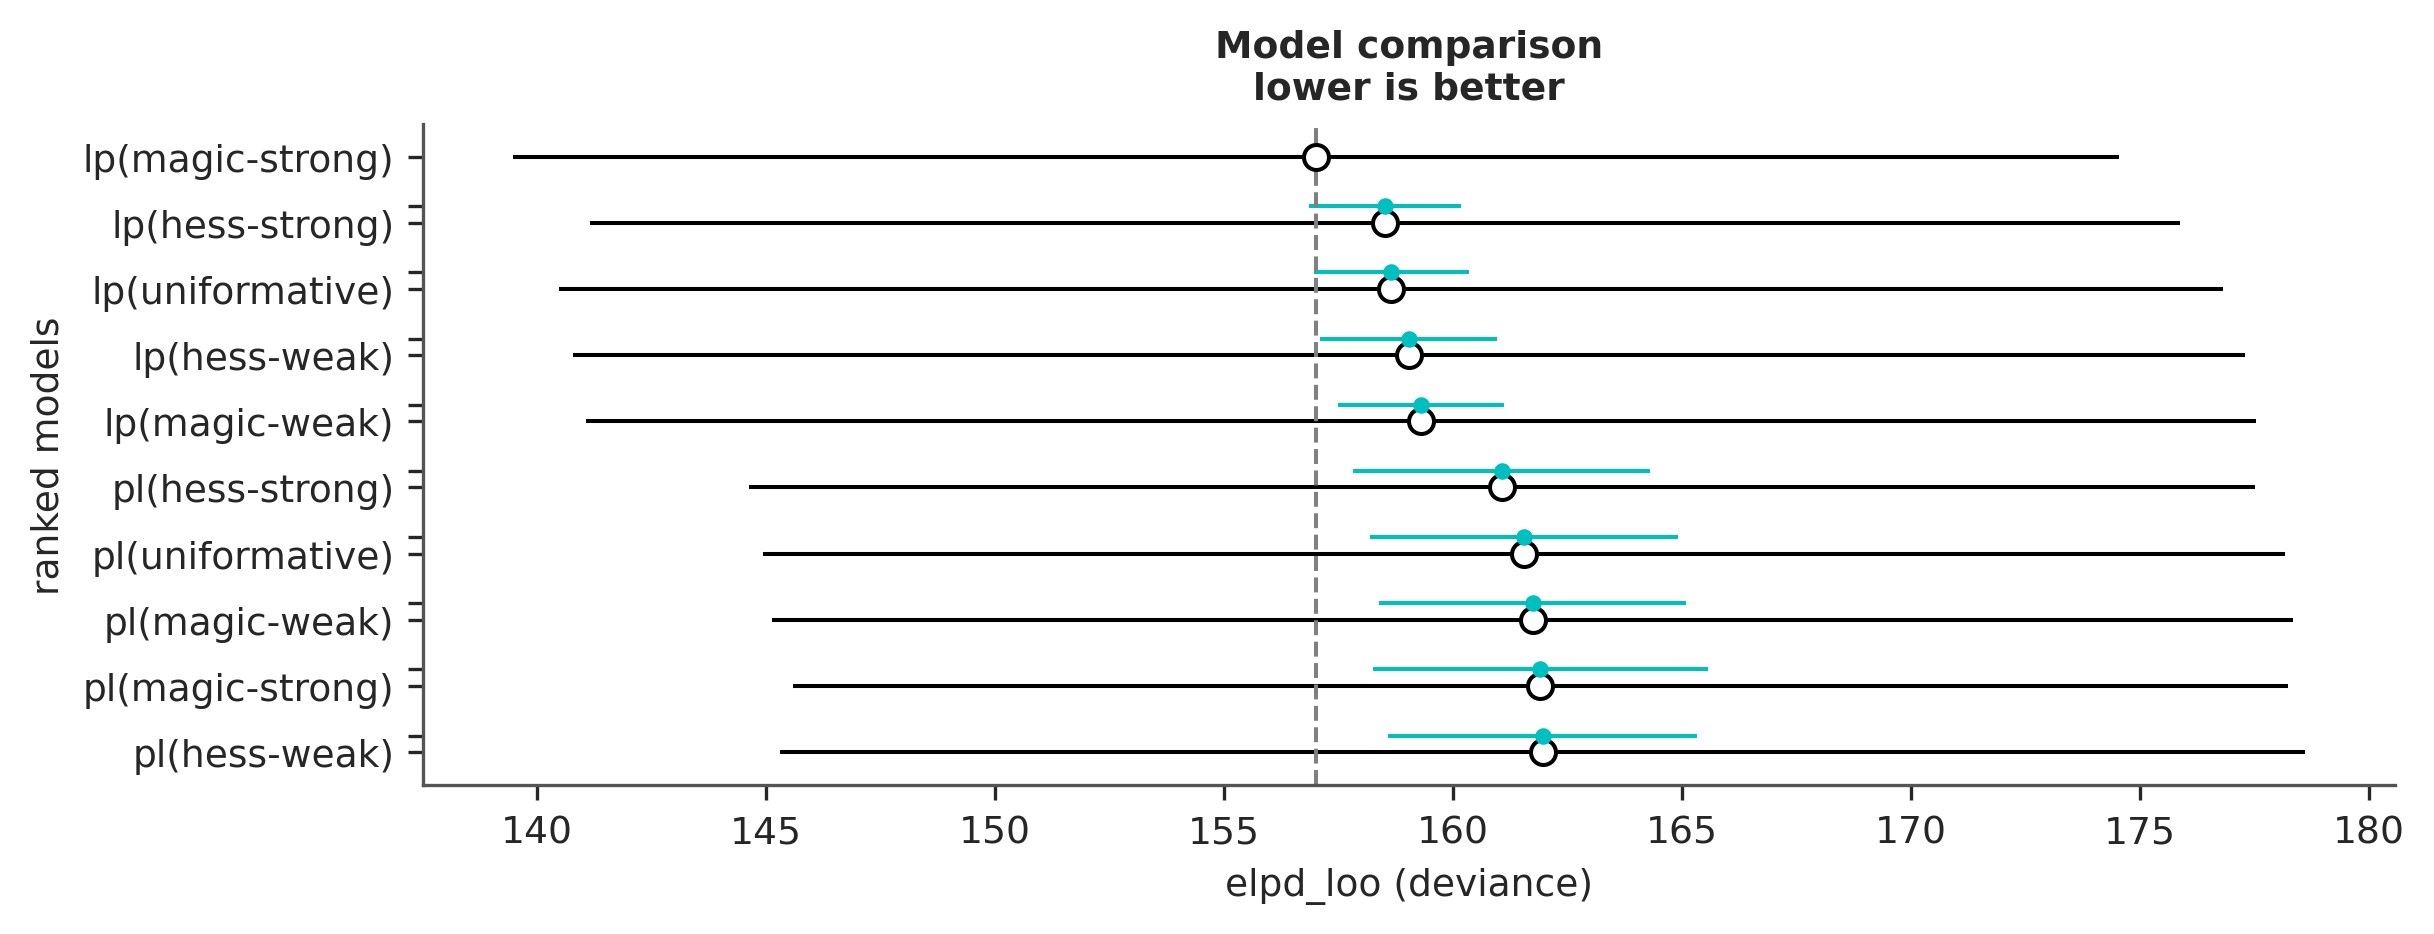

In [49]:
az.plot_compare(
    az_comparison,
    figsize=(8, 3),
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

### Prior and likelihood sensitivity diagnostics

`psens` function compute power-scaling sensitivity diagnostic.
If power-scales the prior or likelihood and calculates how much the posterior is affected.

Higher values returned indicate greater sensitivity. Prior sensitivity above 0.05 indicates informative prior**. Likelihood sensitivity below 0.05 indicates weak or noninformative likelihood.

The result can also be visualized with `psense_summary` function from `arviz_stats` (which is part of `arziv["preview"]` package)
that is attavhed to our result object as `prior_sensitivity_table`

In [50]:
bms_results["lp(uniformative)"].prior_sensitivity_table()

component,prior,likelihood,diagnosis
label,,,
amplitude,0.010,0.088,✓
alpha,0.005,0.080,✓
beta,0.003,0.110,✓


In [51]:
bms_results["lp(magic-strong)"].prior_sensitivity_table()

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


component,prior,likelihood,diagnosis
label,,,
amplitude,0.015,0.081,✓
alpha,0.085,0.065,potential prior-data conflict
beta,0.070,0.087,potential prior-data conflict


In [52]:
bms_results["lp(hess-strong)"].prior_sensitivity_table()

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


component,prior,likelihood,diagnosis
label,,,
amplitude,0.013,0.117,✓
alpha,0.123,0.110,potential prior-data conflict
beta,0.087,0.065,potential prior-data conflict


In [53]:
# bms_results.prior_sensitivity_table() #this will display all the models names and the prior_sensitivity_table

### How to measure the strengh of a prior ?

https://arviz-devs.github.io/EABM/Chapters/Prior_elicitation.html#priors-and-entropy

The entropy is a property of probability distributions the same way the mean or variance are, actually it’s the expected value of the negative log probability of the distribution. We can think of entropy as a measure of the information or uncertainty of a distribution has. Loosely speaking the entropy of a distribution is high when the distribution is spread out and low when the distribution is concentrated. 

In [54]:
print(
    "pl(uniformative), alpha:",
    bms_results["pl(uniformative)"].models[0].spectral_model.index.prior.rv.entropy(),
)
print(
    "pl(magic-strong), aplha:",
    bms_results["pl(magic-strong)"].models[0].spectral_model.index.prior.rv.entropy(),
)

pl(uniformative), alpha: 2.302585092994046
pl(magic-strong), aplha: -0.8836465597893728


### How to define good prior ?

In the context of prior elicitation maximum entropy can be a guiding principle to pick priors. According to this principle we should choose the prior that maximizes the entropy, subject to known constraints of the prior (Jaynes 2003). This is a way to choose a prior that is as vague as possible, given the information we have.

Weakly informative prior should be prefered. It could be based on know sources parameter distributions taken from catalogues.

In [55]:
from gammapy.catalog import CATALOG_REGISTRY

fgl4 = CATALOG_REGISTRY.get_cls("4fgl")()
fgl4 = fgl4.table

Let's filter the catalogue to keep sources with assocations matching one of Galactic source populations

In [56]:
selected_classes = ["PWN", "SNR", "SPP", "SFR", "PSR", "MSP", "BIN", "HMB", "LMB"]
selected_classes += [s.lower() for s in selected_classes]
selection_mask = np.array(
    [str(class1).strip() in selected_classes for class1 in fgl4["CLASS1"]]
)
fgl4_filtered = fgl4[selection_mask]

We load few other catalogues

In [57]:
hgps = CATALOG_REGISTRY.get_cls("hgps")().table
lhaaso1 = CATALOG_REGISTRY.get_cls("1LHAASO")().table
hwc3 = CATALOG_REGISTRY.get_cls("3hwc")().table

We could also use kde to create a distibution model and define a custom prior.
But for now let's create a Gaussian prior.

In [58]:
from gammapy.modeling.models import Model

indexes = np.concatenate(
    (
        fgl4_filtered["PL_Index"].data,
        hgps["Index_Spec_PL"].data,
        lhaaso1["gamma"].data,
        -hwc3["spec0_index"].data,
    )
)
indexes = indexes.data[np.isfinite(indexes)]

spectral_model = Model.create("pl", model_type="spectral")
n_sigma = 2  # could increase for a weaker prior
spectral_model.index.prior = GaussianPrior(
    mu=indexes.mean(), sigma=n_sigma * indexes.std()
)
index_samples = generate_prior_samples([spectral_model.index]).flatten()

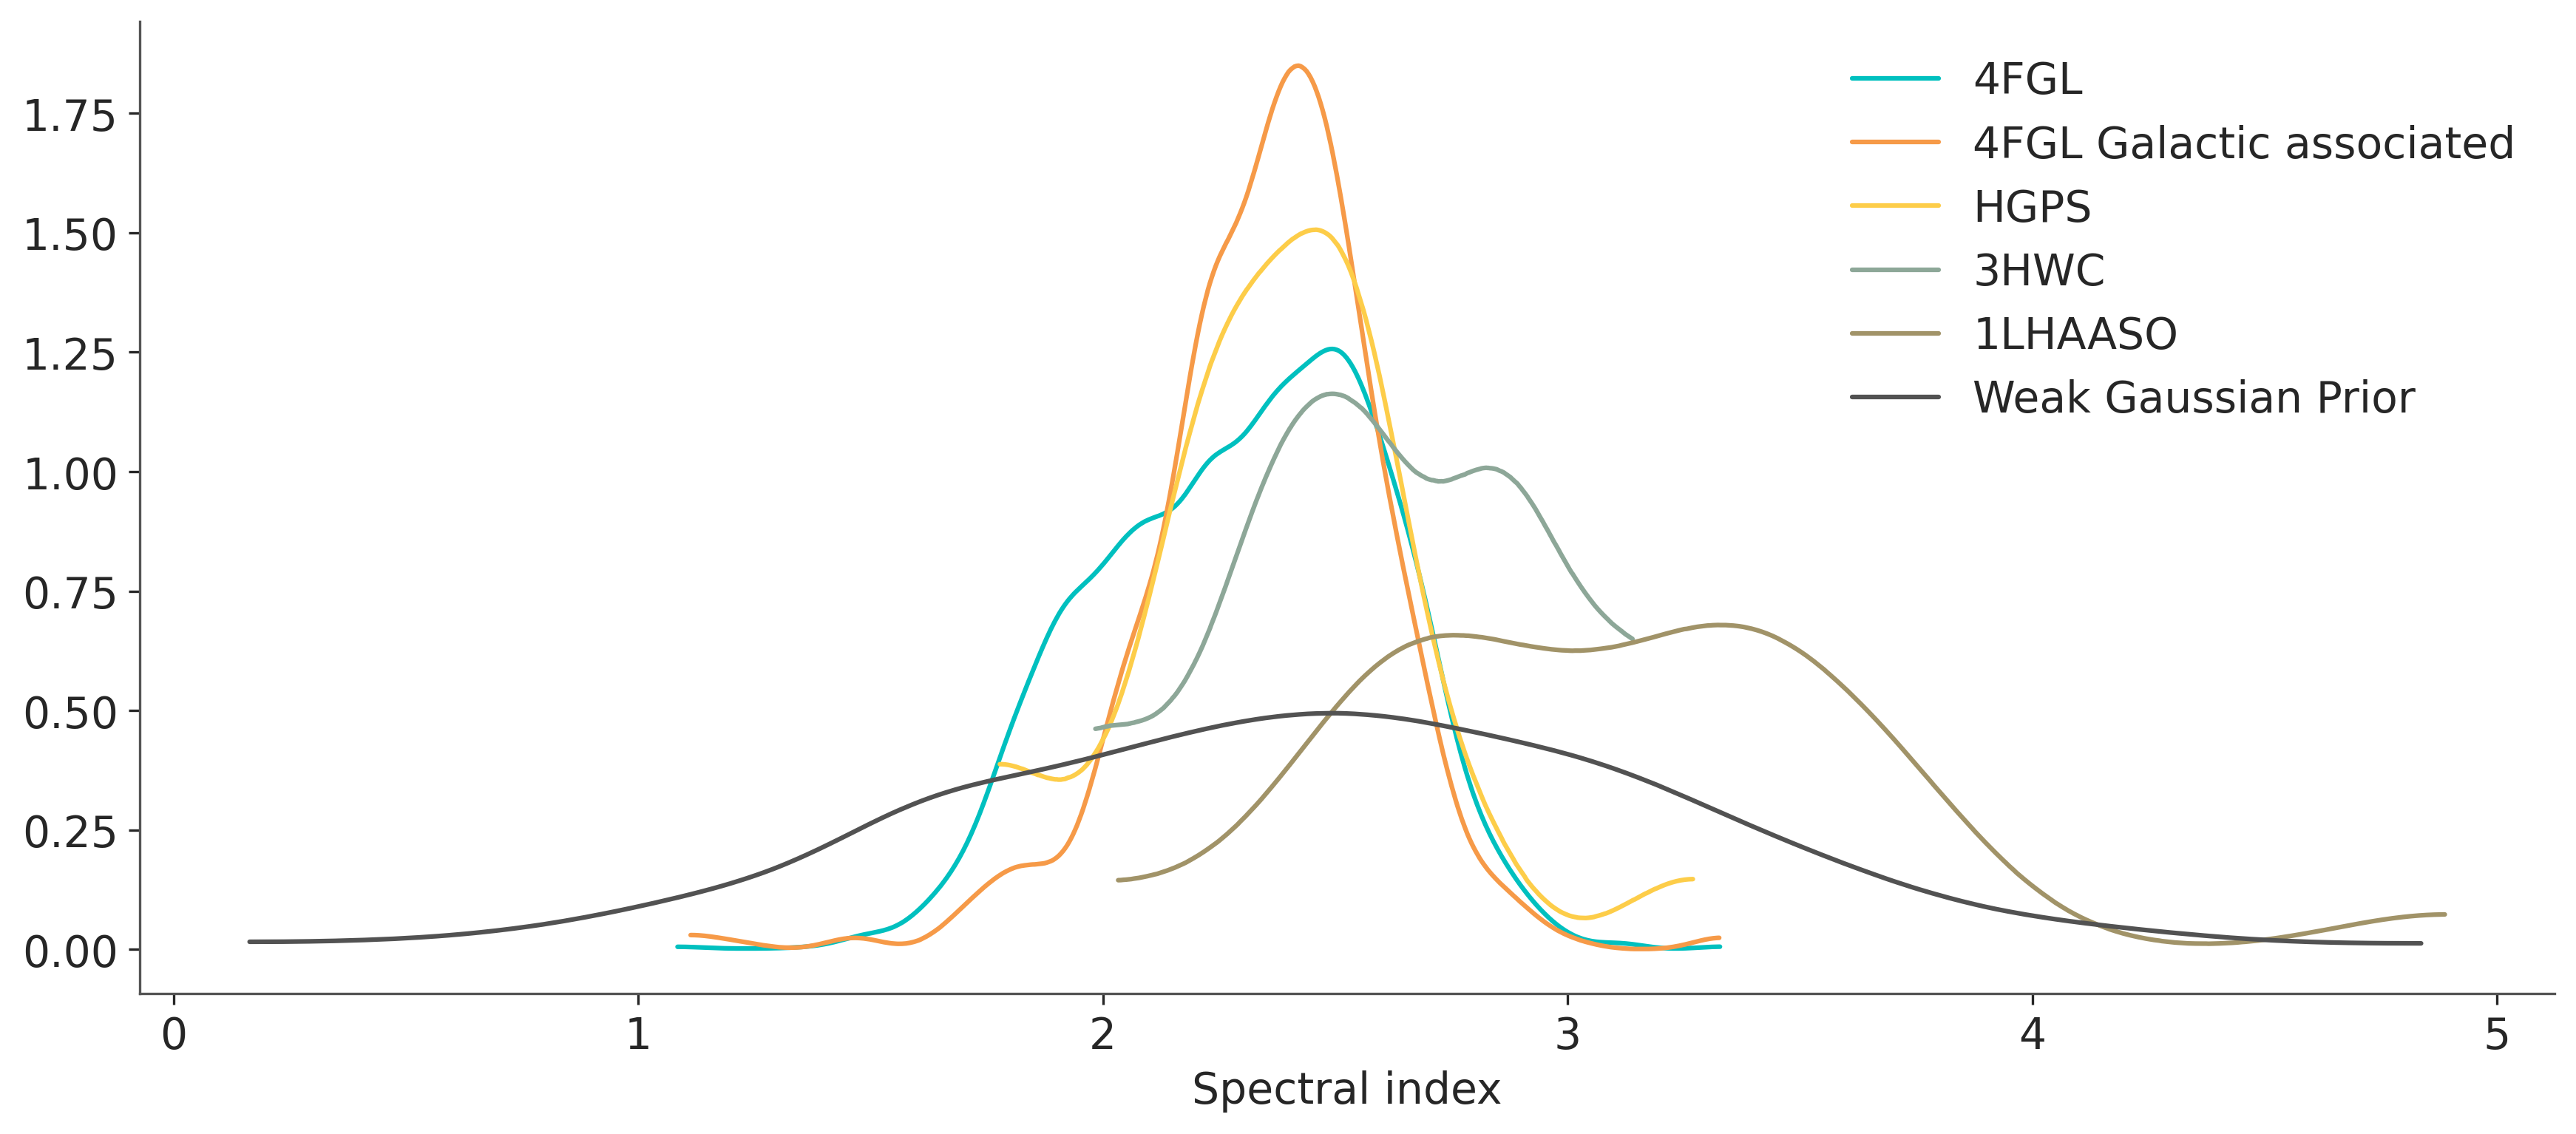

In [59]:
fig, ax = plt.subplots(1, 1)
az.plot_dist(fgl4["PL_Index"].astype(float), color="C1", label="4FGL")
az.plot_dist(
    fgl4_filtered["PL_Index"].astype(float),
    color="C2",
    label="4FGL Galactic associated",
)
az.plot_dist(hgps["Index_Spec_PL"].astype(float), color="C3", label="HGPS")
az.plot_dist(-hwc3["spec0_index"].astype(float), color="C4", label="3HWC")
az.plot_dist(lhaaso1["gamma"].astype(float), color="C5", label="1LHAASO")
az.plot_dist(index_samples, color="C6", label="Weak Gaussian Prior")
ax.set_xlabel("Spectral index")

plt.show()

# Test on simulations

We can check the effect of prior on a simulated dataset where we know the true model. \
First we create a model with a power-law spectrum and we use it to create an Asimov dataset (counts=predicted counts, free of noise).

In [60]:
from gammapy.utils.random import get_random_state

model_name = "hess_pl"
spectral_model = create_crab_spectral_model(model_name)
model_simu = SkyModel(spectral_model=spectral_model, name=f"crab-{model_name}")

datasets.models = model_simu
datasets_asimov = datasets._to_asimov_datasets()

In [61]:
# TODO: same dataset with noise try 1000 times in order to compare mean Monte-Carlo estimate with asimov dataset
# elpd and elpd_err will be different, but heck if the mean of elpd difference and elpd_err difference tends to asimov result
datasets_fake = Datasets()
random_state = get_random_state("random-seed")
for d in datasets:
    npred_signal = d.npred_signal().copy()
    data = np.nan_to_num(npred_signal.data, copy=True, nan=0.0, posinf=0.0, neginf=0.0)
    npred_signal.data = random_state.poisson(data)
    npred_signal.data = npred_signal.data.astype("float")
    fake_dataset = d.__class__(
        models=d.models,
        counts=npred_signal + d.background,
        counts_off=d.counts_off,
        exposure=d.exposure,
        acceptance=d.acceptance,
        acceptance_off=d.acceptance_off,
        psf=d.psf,
        edisp=d.edisp,
        mask_safe=d.mask_safe,
        mask_fit=d.mask_fit,
        gti=d.gti,
        name=d.name,
        meta=d.meta,
    )
    datasets_fake.append(fake_dataset)

Then we run the model selection (we hide the ouptput with capture)

In [62]:
%%capture
bms_results = bms.run(datasets_asimov, alternative_models)

[ultranest] Sampling 500 live points from prior ...
[ultranest] Explored until L=-0.006  
[ultranest] Likelihood function evaluations: 14366
[ultranest]   logZ = -12.95 +- 0.1274
[ultranest] Effective samples strategy satisfied (ESS = 2334.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.13 tail:0.10 total:0.16 required:<0.50
[ultranest] done iterating.
[ultranest] Sampling 500 live points from prior ...
[ultranest] Explored until L=-0.008  
[ultranest] Likelihood function evaluations: 11138
[ultranest]   logZ = -9.67 +- 0.1103
[ultranest] Effective samples strategy satisfied (ESS = 2363.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget

In [63]:
# lower => H0 is better
bms_results.stats_difference_table(reference_models_name="pl(uniformative)")

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str43,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(uniformative) - H1: lp(uniformative),-8.933,-0.006,-2.006,-0.950,-0.951,-1.000,-0.025,-0.025
H0: pl(uniformative) - H1: lp(magic-weak),-2.342,-0.010,-2.010,-1.124,-1.125,-1.000,-0.028,-0.029
H0: pl(uniformative) - H1: lp(magic-strong),7.927,-0.036,-2.036,-0.759,-0.759,-1.000,-0.014,-0.014
H0: pl(uniformative) - H1: lp(hess-weak),-2.369,-0.013,-2.013,-0.994,-0.996,-1.000,-0.030,-0.030
H0: pl(uniformative) - H1: lp(hess-strong),8.128,-0.007,-2.007,-0.242,-0.242,-1.000,0.004,0.004
H0: pl(uniformative) - H1: pl(magic-weak),2.328,-0.000,-0.000,0.129,0.129,0.000,0.001,0.001
H0: pl(uniformative) - H1: pl(magic-strong),8.589,-0.001,-0.001,-0.228,-0.229,0.000,-0.003,-0.003
H0: pl(uniformative) - H1: pl(hess-weak),2.313,-0.000,-0.000,0.100,0.099,0.000,0.003,0.003
H0: pl(uniformative) - H1: pl(hess-strong),10.294,-0.001,-0.001,0.411,0.411,0.000,0.009,0.009


Again the bayesian evidence can favor the wrong model if they are tested with stronger priors than the true model. 
While the ELPD always favor the true model and rank them as expected from their deviation to the true model (pl-hess).

<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

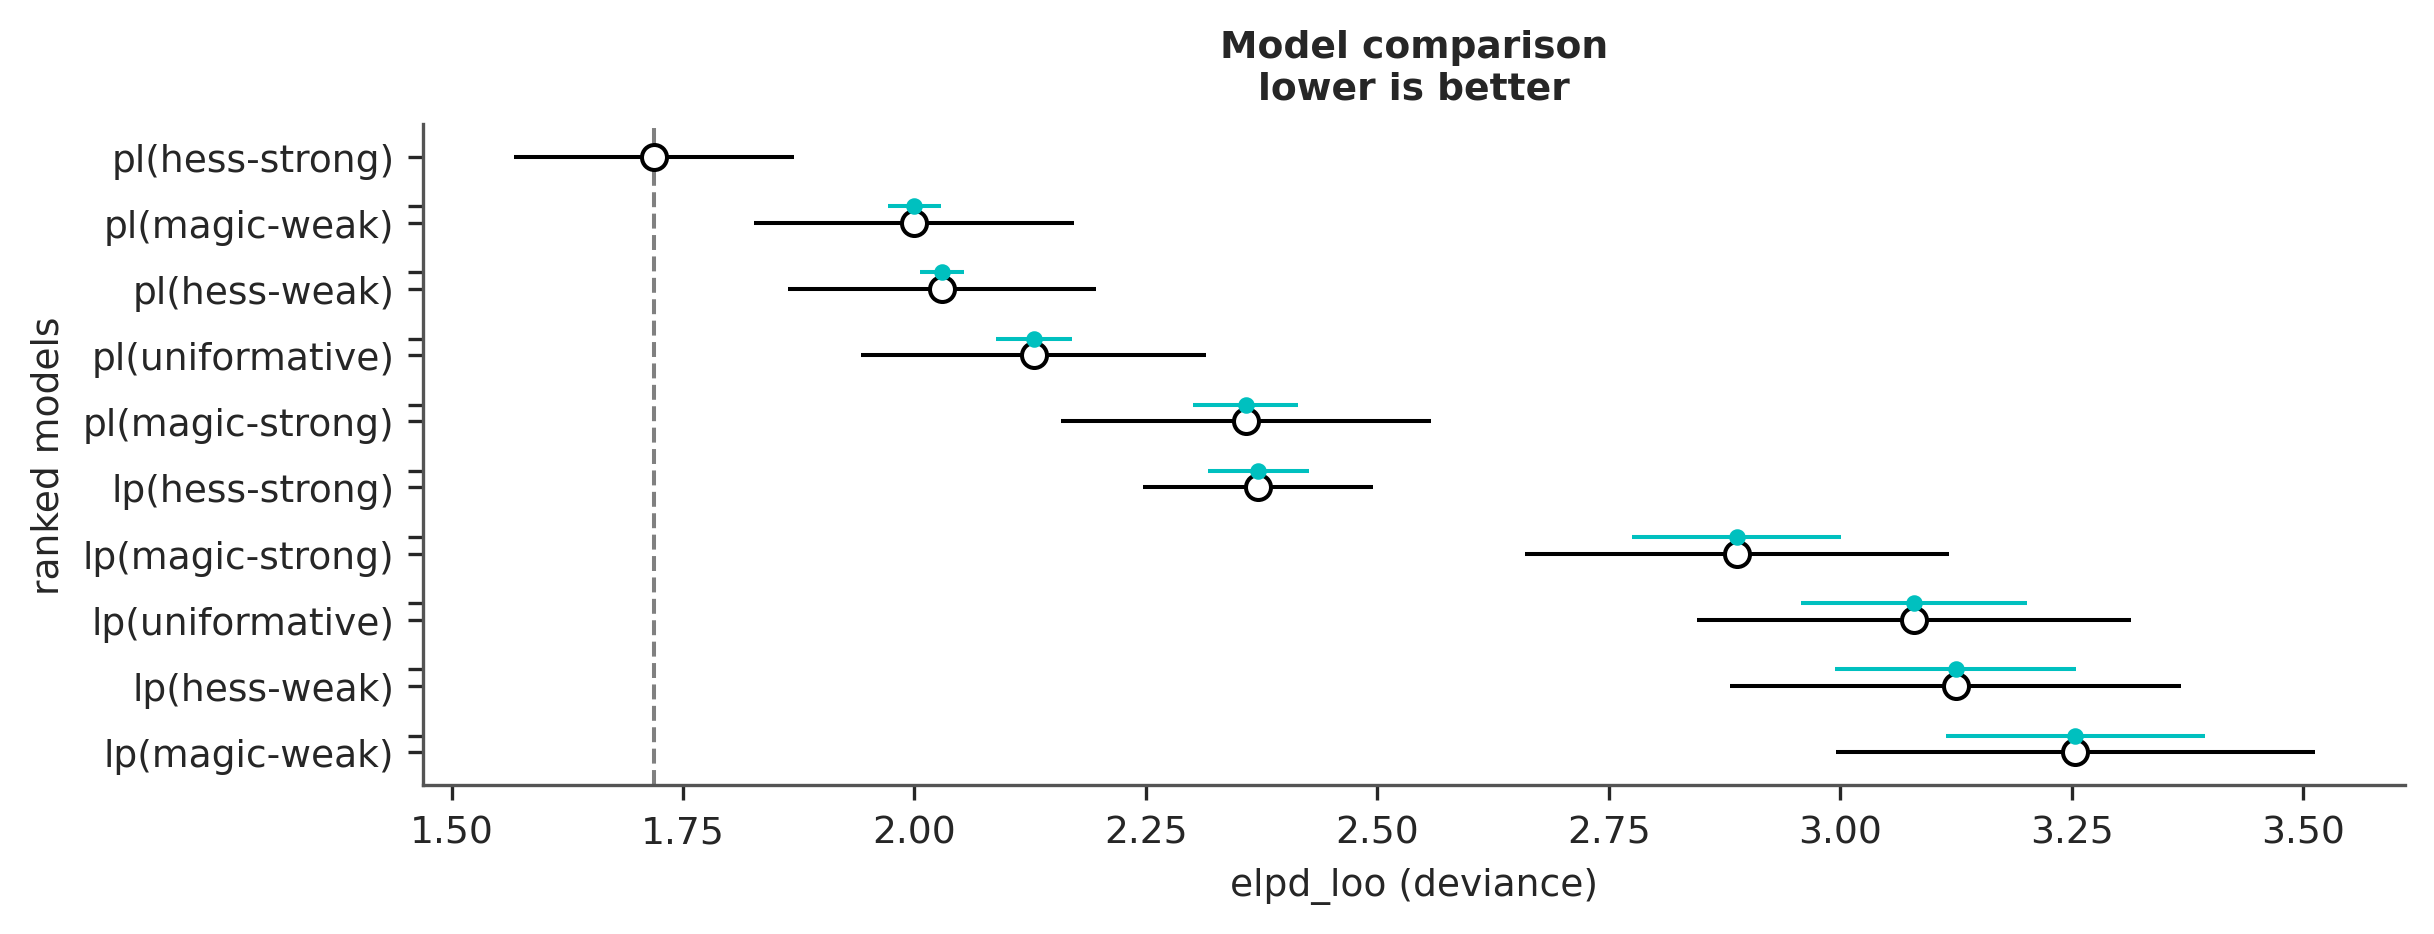

In [64]:
compare = bms_results.compare()
az.plot_compare(
    compare,
    figsize=(8, 3),
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

In [65]:
compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
pl(hess-strong),0,1.718355,0.019383,0.000000,0.142762,0.151440,0.000000,False,deviance
pl(magic-weak),1,1.999635,0.027028,0.281280,0.123951,0.173225,0.028629,False,deviance
pl(hess-weak),2,2.029675,0.025583,0.311320,0.122120,0.166607,0.023357,False,deviance
pl(uniformative),3,2.129064,0.028117,0.410709,0.116143,0.186452,0.041166,False,deviance
pl(magic-strong),4,2.357873,0.031562,0.639518,0.103566,0.199689,0.056590,False,deviance
lp(hess-strong),5,2.371439,0.023643,0.653084,0.103121,0.124047,0.054798,False,deviance
lp(magic-strong),6,2.888345,0.041987,1.169990,0.079445,0.229066,0.112986,False,deviance
lp(uniformative),7,3.079815,0.053124,1.361460,0.072186,0.234827,0.122533,False,deviance
lp(hess-weak),8,3.124782,0.058514,1.406427,0.070572,0.243766,0.129899,False,deviance
lp(magic-weak),9,3.254172,0.056777,1.535817,0.066135,0.258792,0.139832,False,deviance


The power-lar model with a wrong strong prior are very influencial and the mean of the parameters posteriors (black points) deviates from the truth (orange points)

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/plots/pairplot.py:229: UserWarning: Divergences data not found, plotting without divergences. Make sure the sample method provides divergences data and that it is present in the `diverging` field of `sample_stats` or `sample_stats_prior` or set divergences=False
  warnings.warn(


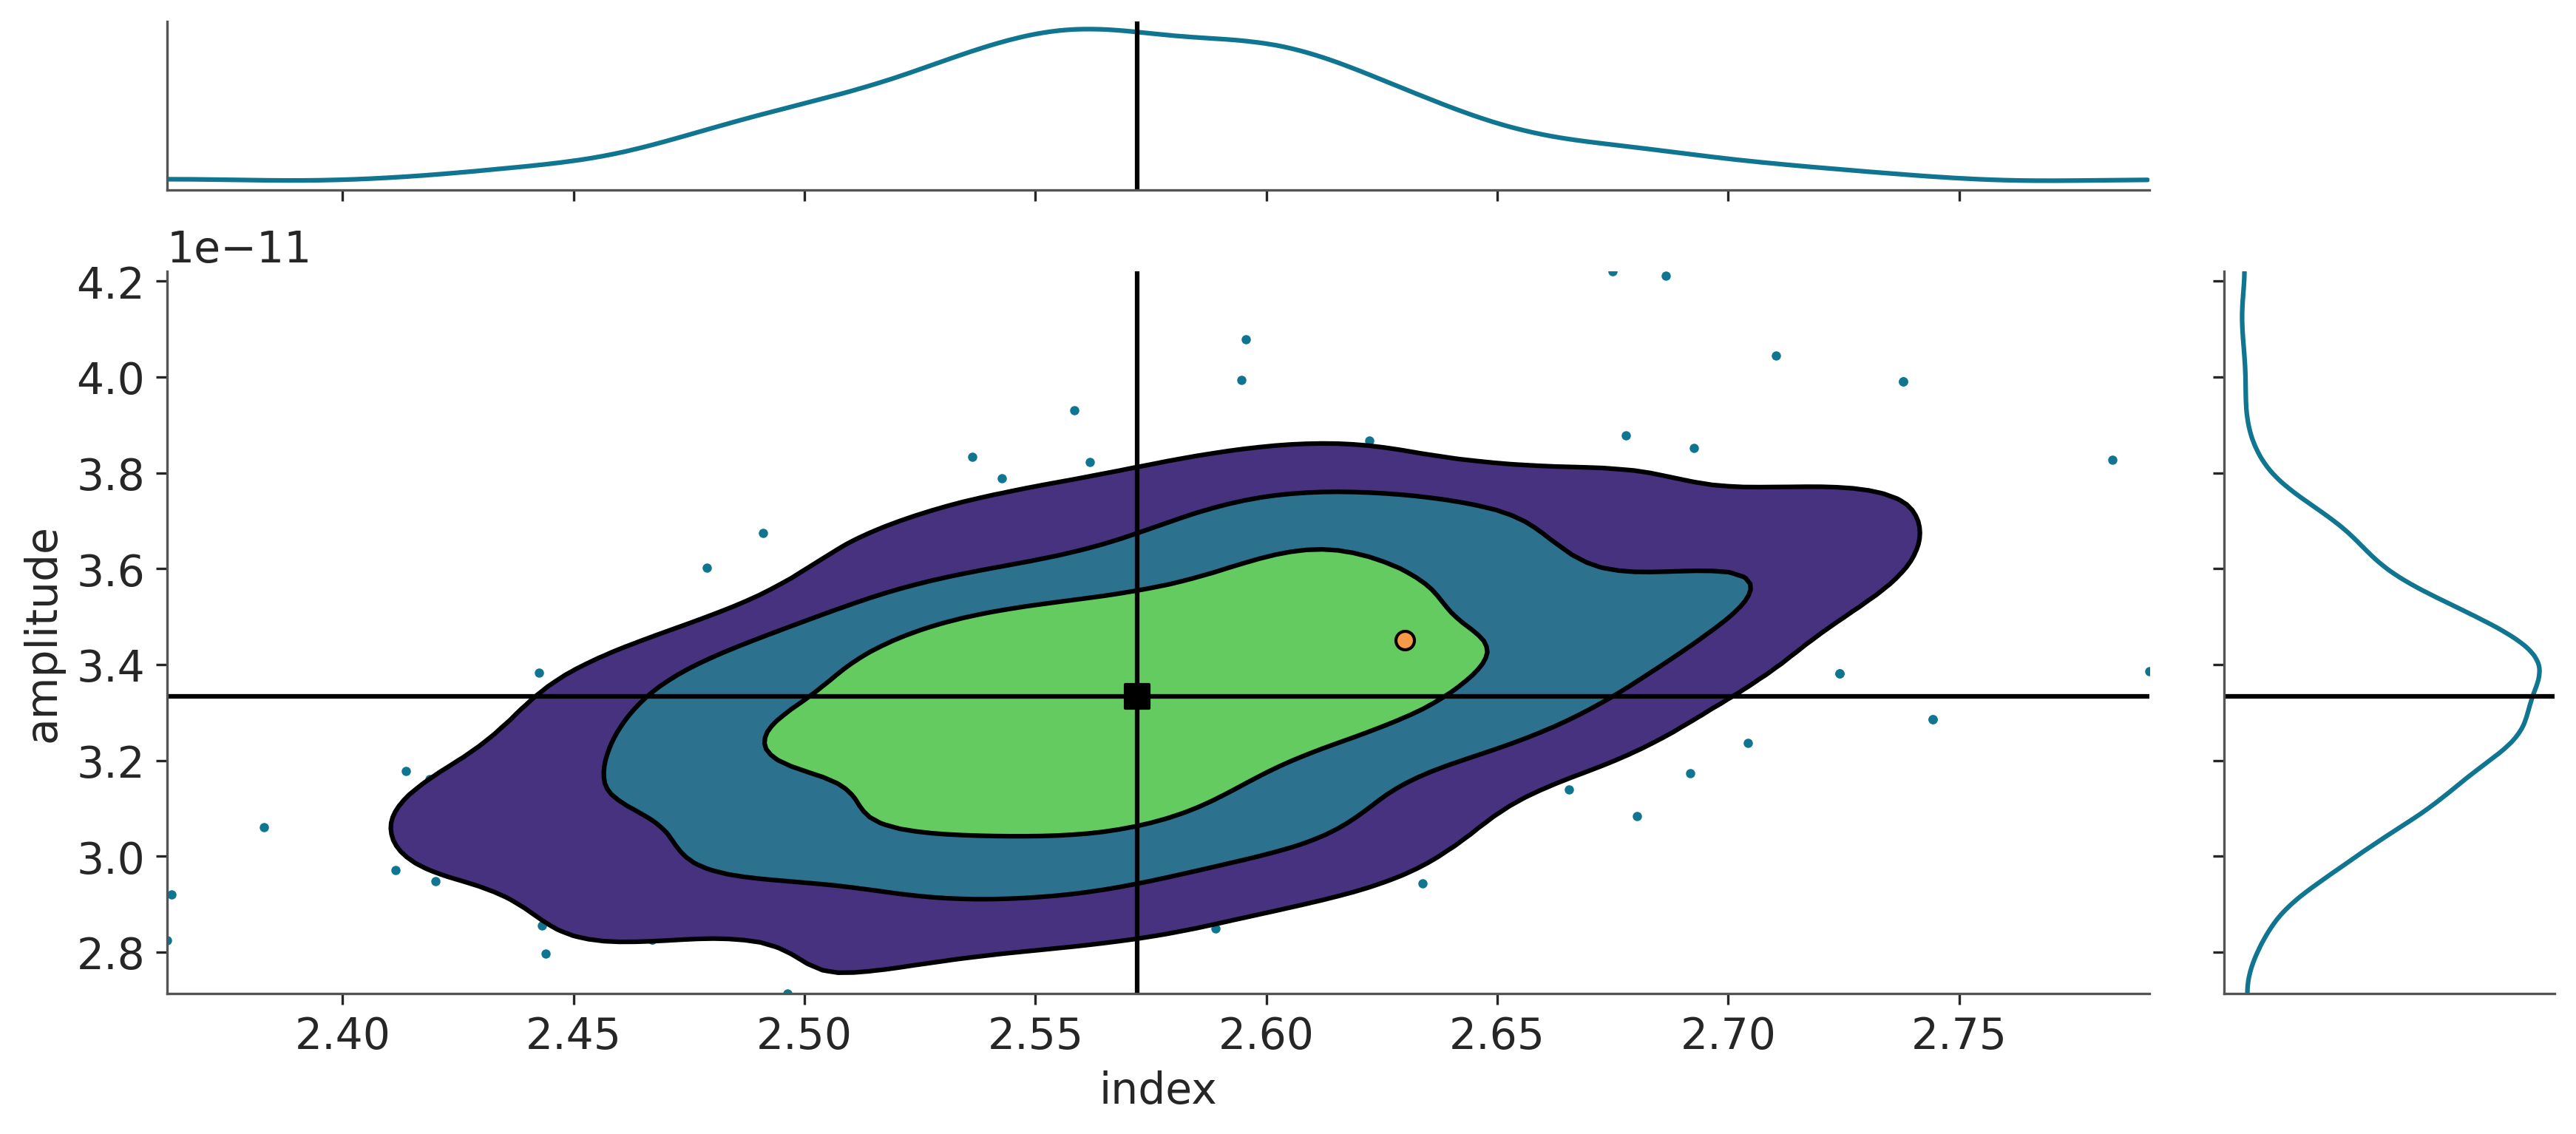

In [66]:
ax = az.plot_pair(
    bms_results["pl(magic-strong)"].unweighted_inference_data,
    kind=["scatter", "kde"],
    kde_kwargs={"fill_last": False},
    marginals=True,
    colorbar=True,
    divergences=True,
    point_estimate="mean",
    reference_values={
        par.name: par.value for par in model_simu.parameters.free_unique_parameters
    },
    figsize=(11.5, 5),
)

while it's not the case for weaker a prior

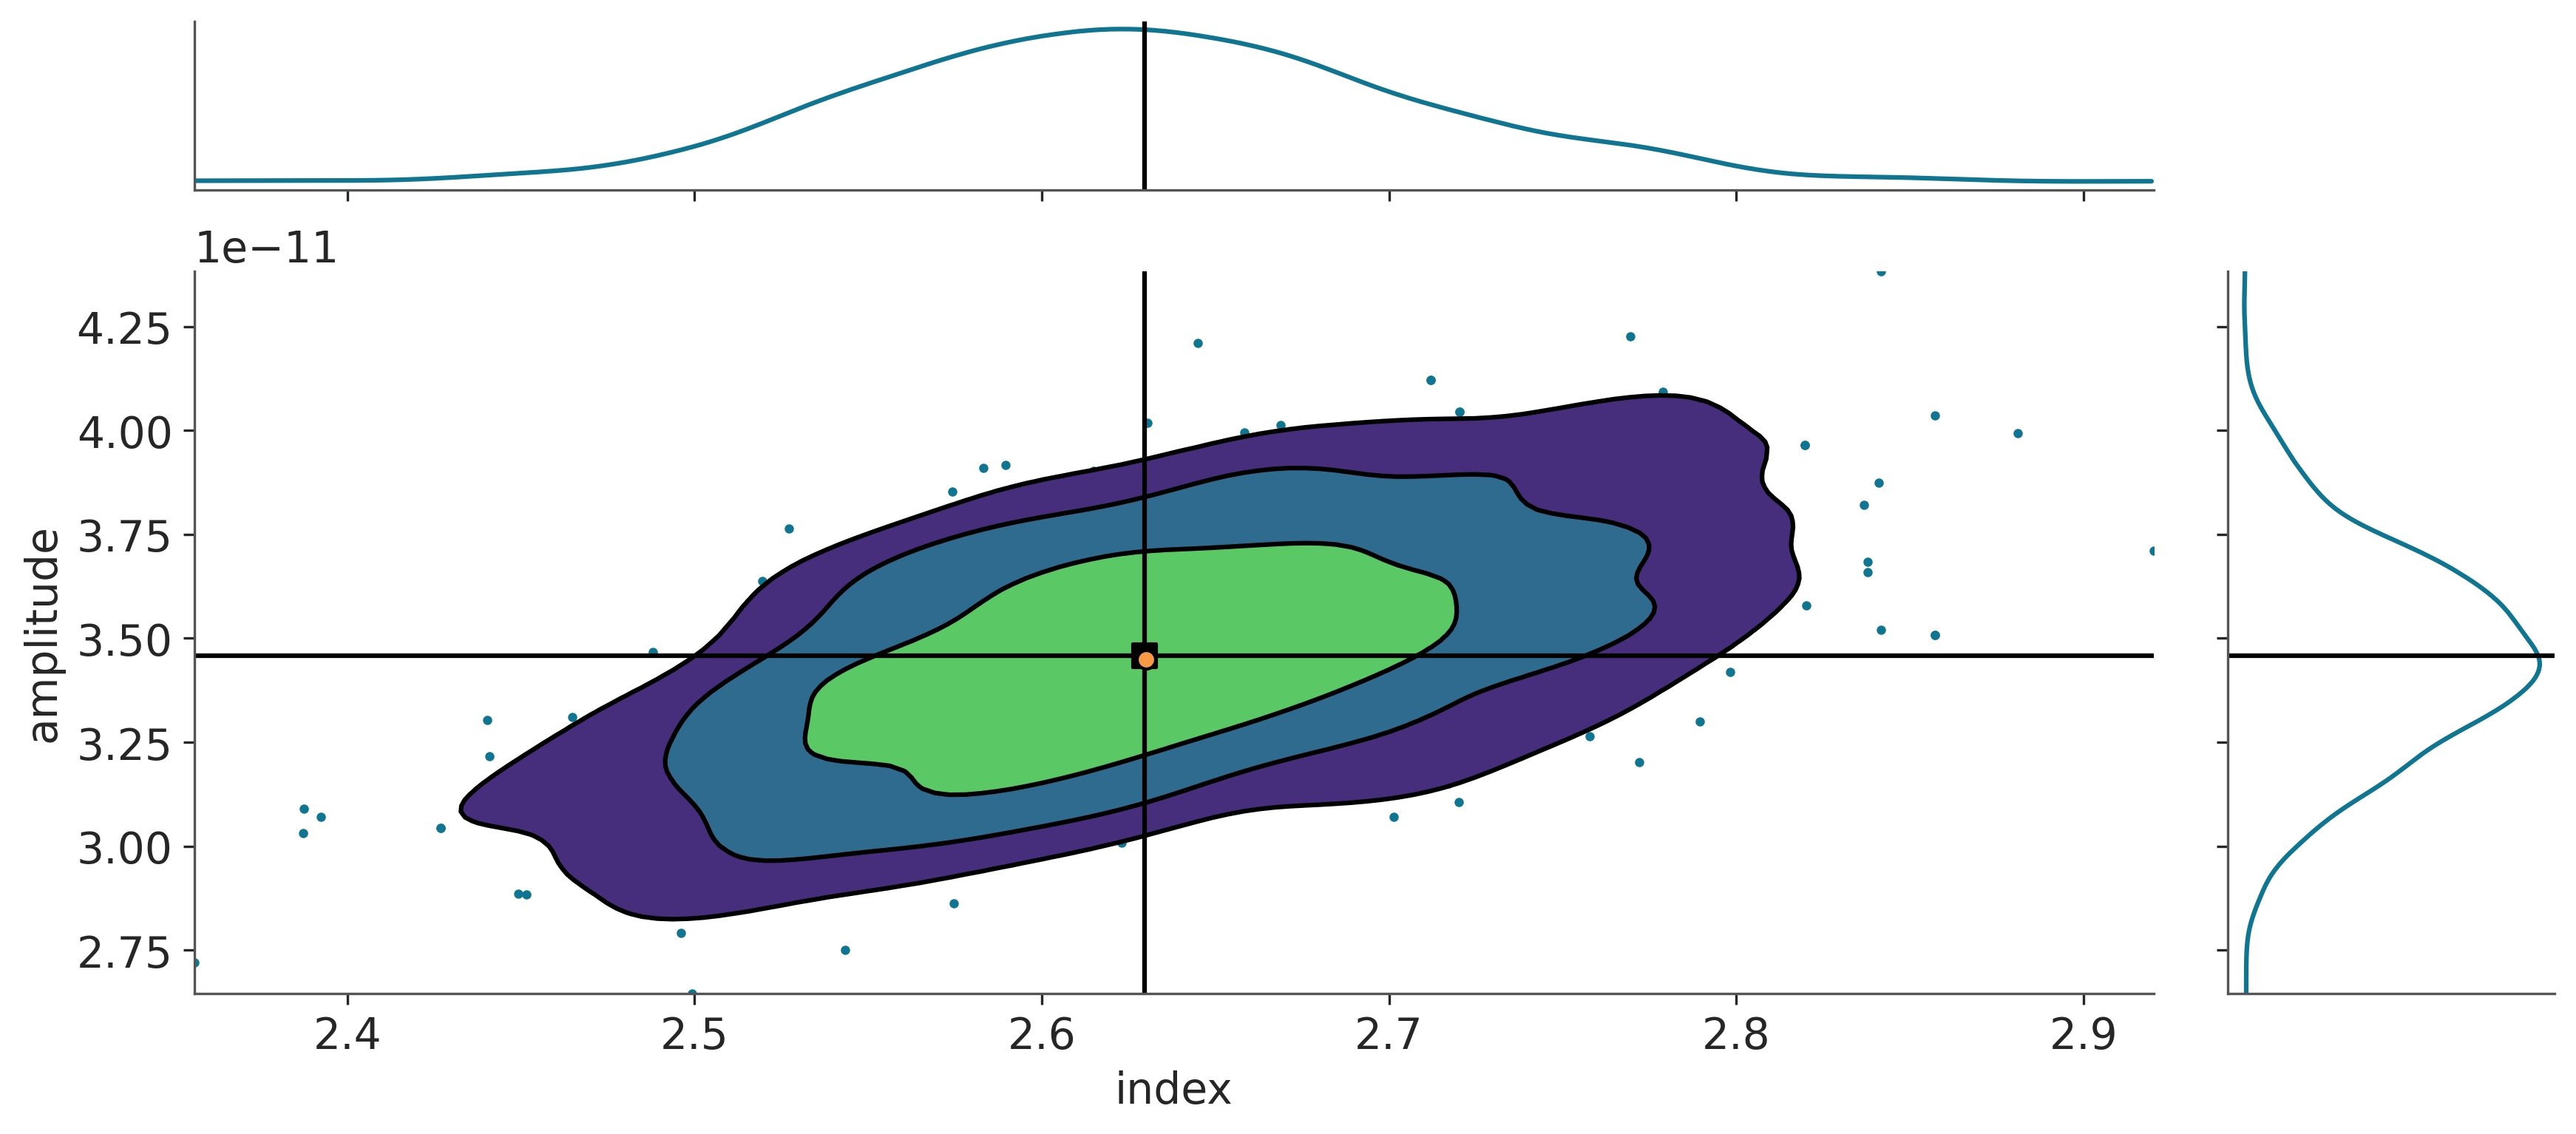

In [67]:
ax = az.plot_pair(
    bms_results["pl(magic-weak)"].unweighted_inference_data,
    kind=["scatter", "kde"],
    kde_kwargs={"fill_last": False},
    marginals=True,
    colorbar=True,
    divergences=True,
    point_estimate="mean",
    reference_values={
        par.name: par.value for par in model_simu.parameters.free_unique_parameters
    },
    figsize=(11.5, 5),
)

# 3D analysis example


In [68]:
datasets_3d = Datasets.read(
    "datasets_3d_hess_rjj1713_.yaml", "models_3d_hess_rjj1713_.yaml"
)
models_template = datasets_3d.models

datasets_3d = Datasets([d.downsample(factor=5) for d in datasets_3d])
# TODO: compare how the parameters and the elpd and elpd_err diffs are affected by the downsampling of the dataset
# try  factor = 1,2,5,10,25

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
HDU 'MASK_FIT' not found


In [69]:
import astropy.units as u

for d in datasets_3d:
    d.mask_fit = d.mask.geom.boundary_mask((0.5 * u.deg, 1 * u.deg))
# (d.counts*d.mask_fit).plot_interactive()

In [70]:
models_template["RXJ1713"].parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,2.0565e-17,MeV-1 s-1 cm-2,1.075e-18,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,alpha,1.7770e+00,,9.446e-02,nan,nan,False,,
,beta,2.0921e-01,,4.798e-02,nan,nan,False,,
,lon_0,2.5839e+02,deg,0.000e+00,nan,nan,True,,
,lat_0,-3.9762e+01,deg,0.000e+00,-9.000e+01,9.000e+01,True,,


In [71]:
models_template["RXJ1713"].position.galactic

<SkyCoord (Galactic): (l, b) in deg
    (347.33283615, -0.47272957)>

In [72]:
from gammapy.modeling.models import Shell2SpatialModel, GeneralizedGaussianSpatialModel

models_template.freeze()
models_template["RXJ1713"].unfreeze("spectral")
models_template["RXJ1713"].spectral_model.amplitude.prior = LogUniformPrior(
    min=8e-18, max=5e-16
)
models_template["RXJ1713"].spectral_model.alpha.prior = UniformPrior(min=1.5, max=2.5)
models_template["RXJ1713"].spectral_model.beta.prior = UniformPrior(min=0, max=0.5)

pos = models_template["RXJ1713"].position.galactic
models_shell = models_template.copy()
models_shell["RXJ1713"].spatial_model = Shell2SpatialModel(
    lon_0=pos.l, lat_0=pos.b, r_0=0.5 * u.deg, eta=0.5, frame="galactic"
)
models_shell["RXJ1713"].spatial_model.lon_0.prior = UniformPrior(
    min=pos.l.value - 0.3, max=pos.l.value + 0.3
)
models_shell["RXJ1713"].spatial_model.lat_0.prior = UniformPrior(
    min=pos.b.value - 0.3, max=pos.b.value + 0.3
)
models_shell["RXJ1713"].spatial_model.r_0.prior = UniformPrior(min=0.2, max=0.9)
models_shell["RXJ1713"].spatial_model.eta.prior = UniformPrior(min=0.1, max=0.7)

models_disk = models_template.copy()
models_disk["RXJ1713"].spatial_model = GeneralizedGaussianSpatialModel(
    lon_0=pos.l, lat_0=pos.b, r_0=0.5 * u.deg, eta=0.1, frame="galactic"
)
models_disk["RXJ1713"].spatial_model.lon_0.prior = UniformPrior(
    min=pos.l.value - 0.3, max=pos.l.value + 0.3
)
models_disk["RXJ1713"].spatial_model.lat_0.prior = UniformPrior(
    min=pos.b.value - 0.3, max=pos.b.value + 0.3
)
models_disk["RXJ1713"].spatial_model.r_0.prior = UniformPrior(min=0.1, max=0.7)
models_disk["RXJ1713"].spatial_model.eta.frozen = True

alternative_models_3d = {
    "fermi-template": models_template,
    "disk": models_disk,
    "shell": models_shell,
}

Let's change the sampler parameters so it's faster (3d is more time consunming because the models have to be convolved by the PSF)

In [73]:
sampler_opts_3d = {
    "live_points": 200,
    "frac_remain": 0.3,
    "log_dir": None,
}
sampler_3d = Sampler(sampler_opts=sampler_opts_3d)
bms_3d = BayesianModelSelection(
    sampler_3d, prosterior_reduction_factor=4, n_prior_samples=None
)

bms_results_3d = bms_3d.run(datasets_3d, alternative_models_3d)

Model HESS J1708-410 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.


Evaluating fermi-template


Model HESS J1718-385 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.


[ultranest] Sampling 200 live points from prior ...


[ultranest] Explored until L=5e+03  5.31 [5304.6249..5304.6259]*| it/evals=1570/3057 eff=54.9527% N=200 0 
[ultranest] Likelihood function evaluations: 3060
[ultranest]   logZ = 5298 +- 0.1426
[ultranest] Effective samples strategy satisfied (ESS = 762.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.30, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.14 tail:0.26 total:0.30 required:<0.50
[ultranest] done iterating.

logZ = 5298.269 +- 0.456
  single instance: logZ = 5298.269 +- 0.164
  bootstrapped   : logZ = 5298.301 +- 0.373
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000000000180│ ▁▁▁▁▁▁▂▂▂▃▃▅▅▆▇▇▇▆▆▆▅▅▃▂▂▂▂▁▁▁▁▁   ▁▁ │0.0000000000000000261    0.0000000000000000217 +- 0.0000000000000000010
    alpha               : 1.50  │▁▁▁▁▁▁▂▁▁▂▂▃▄▄▄▄▆▆▇▅▇▇▆▆▇▅▃▄▃▃▂▁▁▁

...

[ultranest] Sampling 200 live points from prior ...


[ultranest] Explored until L=5e+03  7.66 [5295.6765..5295.6785]*| it/evals=3265/23937 eff=13.7507% N=199 
[ultranest] Likelihood function evaluations: 23937
[ultranest]   logZ = 5281 +- 0.2004
[ultranest] Effective samples strategy satisfied (ESS = 849.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.33, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.20 tail:0.26 total:0.33 required:<0.50
[ultranest] done iterating.

logZ = 5281.250 +- 0.548
  single instance: logZ = 5281.250 +- 0.253
  bootstrapped   : logZ = 5281.264 +- 0.481
  tail           : logZ = +- 0.263
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000000000182│ ▁▁▁▁▂▁▂▂▄▅▅▆▅▆▇▇▇▆▅▅▅▄▃▃▂▃▂▁▁▁▁▁ ▁▁ ▁ │0.0000000000000000273    0.0000000000000000221 +- 0.0000000000000000013
    alpha               : 1.50  │▁▁▁▁▁▁▂▂▂▃▄▄▅▆▇▇▇▆▅▇▅▆▆▅▆▄▃▂▃▂▁▁▁▁

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,2.1990488176085205e-17,2.192069953303807e-17,2.1859003697200766e-17,2.1851982475406917e-17
alpha,1.818826219563575,1.8169653089883833,1.7731882307091633,1.8594114756193845
beta,0.20630876194236009,0.20563912474742257,0.20314410878412997,0.16986164390934505
lon_0,347.2899512494165,347.2912104217538,347.2939256848611,347.29839344297
lat_0,-0.4415779857066871,-0.44155425386431224,-0.4404220109776401,-0.44405942157710454
r_0,0.5969254639223563,0.5945398024145805,0.5874790643557208,0.5775748621237853
eta,0.5173544314195402,0.5115571151029226,0.492107622654243,0.5007894885583807


Statistics summary in deviance scale : -2log(score)
A lower deviance corresponds to a model with better predictive accuracy. 
-2log(Z)  : -10562.500142832494 +/- 1.096958109066228
-2log(L)  : -10595.319631974158
AIC       : -10581.319631974158, dof 7
elpd_waic : -10578.542149979166+/-678.8296586940721, effective dof 10.377789356746485
elpd_loo  : -10578.502315162827,+/-678.8287035999532, effective dof 10.39770676491662



In [74]:
bms_results_3d.stats_table()

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof,logz error,elpd error (waic),elpd error (loo),good Pareto k fraction
str14,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
fermi-template,-10596.539,-10610.613,-10604.613,-10604.632,-10604.579,3.000,2.978,3.004,0.911,678.722,678.721,1.000
disk,-10558.022,-10588.669,-10576.669,-10575.950,-10575.861,6.000,6.949,6.994,0.917,678.705,678.704,0.949
shell,-10562.500,-10595.320,-10581.320,-10578.542,-10578.502,7.000,10.378,10.398,1.097,678.830,678.829,0.887


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

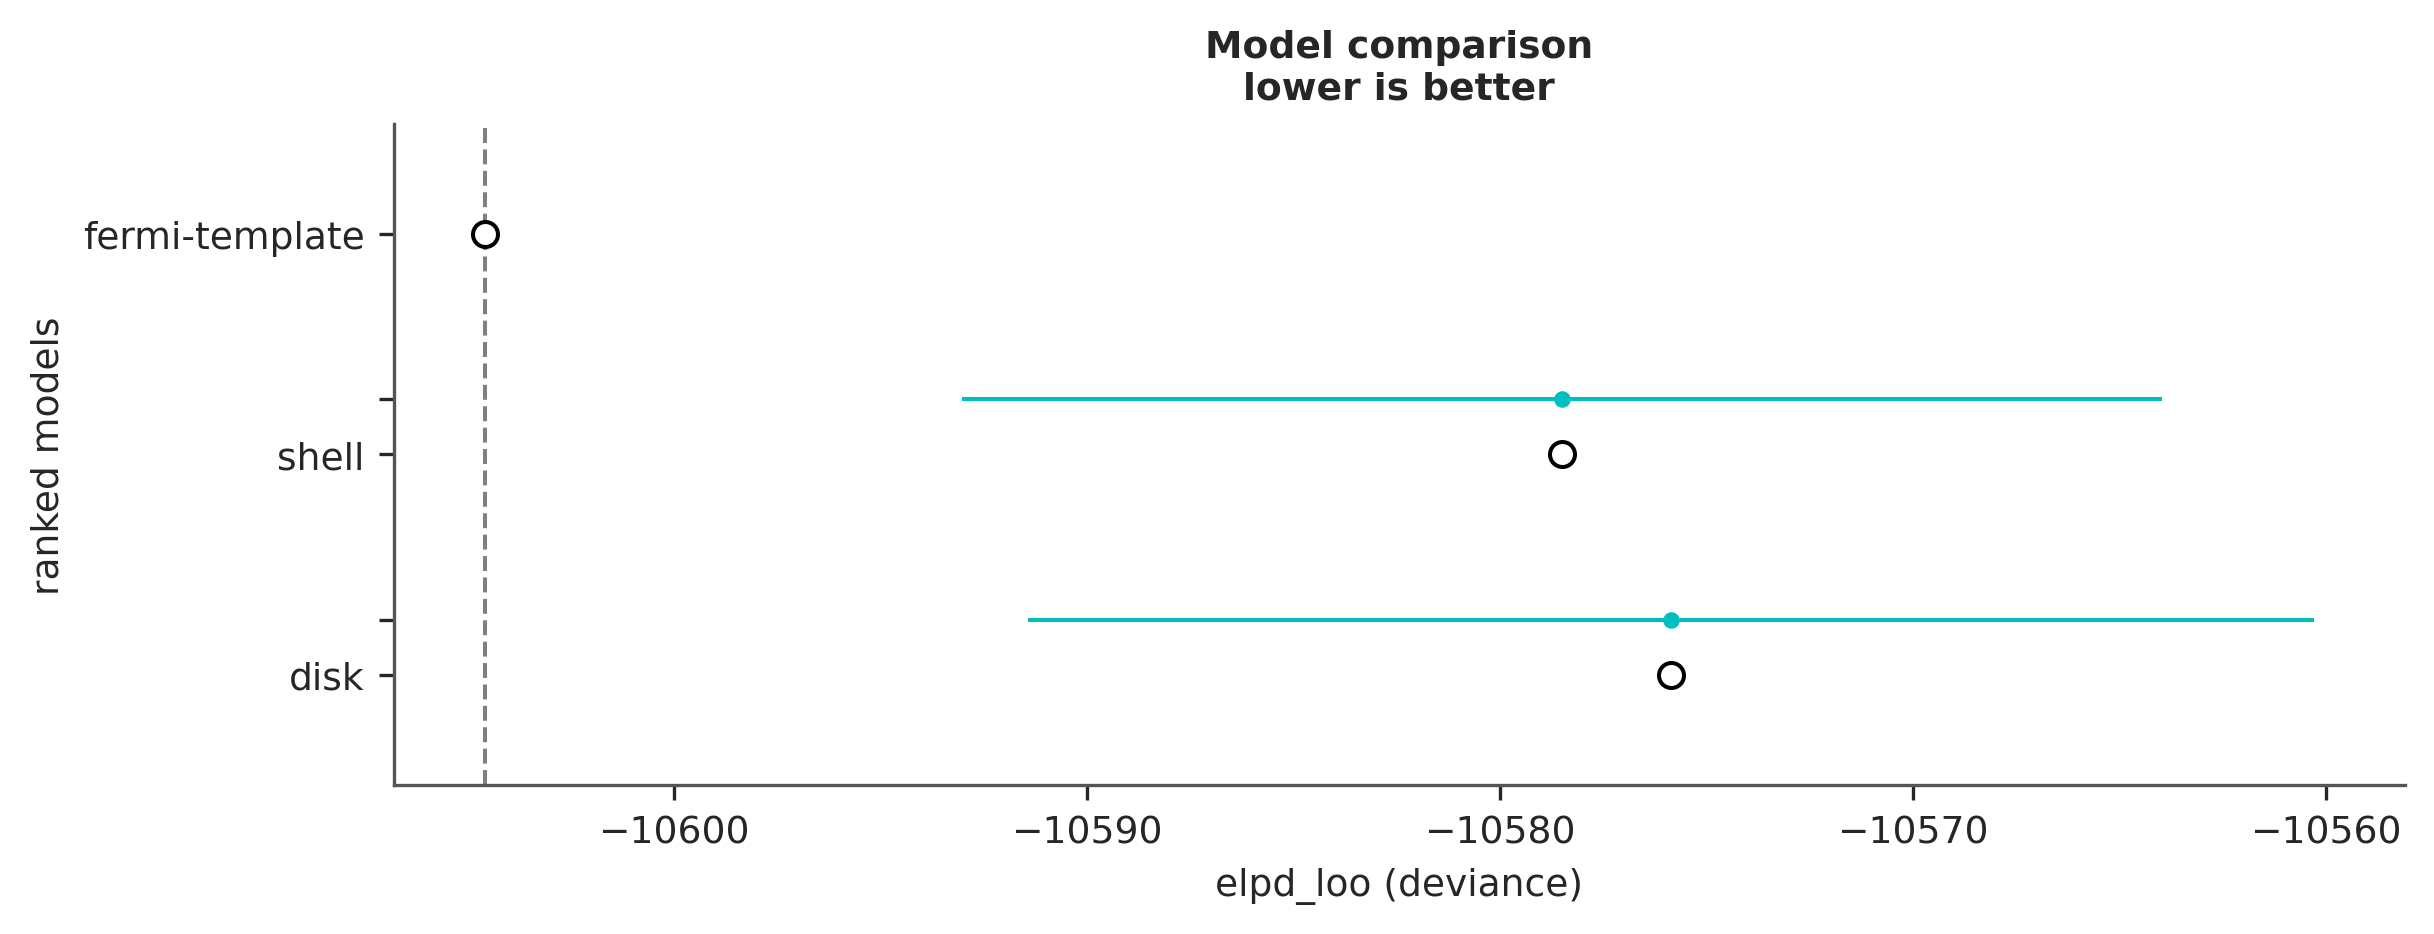

In [75]:
compare_3d = bms_results_3d.compare()
az.plot_compare(
    compare_3d,
    figsize=(8, 3),
    plot_standard_error=False,
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

In [76]:
compare_3d

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
fermi-template,0,-10604.579078,3.004143,0.000000,0.945493,659.593432,0.000000,False,deviance
shell,1,-10578.502315,10.397707,26.076763,0.030424,659.264533,14.531476,True,deviance
disk,2,-10575.860780,6.993935,28.718298,0.024083,658.949026,15.559245,True,deviance


We see there is a warning so we can look at the elpd_loo printout for details

In [77]:
bms_results_3d["shell"].elpd_loo

Computed from 825 posterior samples and 4000 observations log-likelihood matrix.

             Estimate       SE
deviance_loo -10578.50   678.83
p_loo           10.40        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.66]   (good)     3548   88.7%
   (0.66, 1]   (bad)        33    0.8%
   (1, Inf)   (very bad)  419   10.5%

The Pareto k is bad for some pixels in that case, we could inspect which one (missing function to go back from flatten space to 3d cube). 
Eventually we might have to perform the exact LOO for these pixels (or mask them ?).

In [78]:
bms_results_3d.prior_sensitivity_table()

fermi-template


component,prior,likelihood,diagnosis
label,,,
amplitude,0.008,0.092,✓
alpha,0.002,0.119,✓
beta,0.001,0.110,✓


disk


component,prior,likelihood,diagnosis
label,,,
amplitude,0.009,0.075,✓
alpha,0.002,0.094,✓
beta,0.001,0.102,✓
lon_0,0.002,0.148,✓
lat_0,0.001,0.103,✓
r_0,0.004,0.150,✓


shell


component,prior,likelihood,diagnosis
label,,,
amplitude,0.009,0.081,✓
alpha,0.002,0.081,✓
beta,0.001,0.078,✓
lon_0,0.002,0.088,✓
lat_0,0.001,0.098,✓
r_0,0.004,0.137,✓
eta,0.002,0.132,✓
